<div align="center">

## Fighting Barren Plateaus in Volatility Forecasting for Highly Liquid Assets

### Борьба с Barren Plateau при прогнозировании волатильности высоколиквидных активов (индекс МосБиржи, MOEX)
</div>

### Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, auc, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

from sklearn.preprocessing import MinMaxScaler

import pennylane as qml
import torch
import torch.nn as nn

torch.manual_seed(42)
np.random.seed(42)

### Additional functions

In [2]:
def plot_decision_boundary(model, X, y, title, is_torch=False):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    if is_torch:
        with torch.no_grad():
            Z = model(torch.tensor(grid, dtype=torch.float32)).numpy()
    else:
        Z = model.predict_proba(grid)[:, 1]

    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(7,5))
    plt.contourf(xx, yy, Z, levels=30, cmap="coolwarm", alpha=0.6)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", s=25, edgecolor="k")
    plt.title(title)
    plt.xlabel("key_rate (standardized)")
    plt.ylabel("inflation (standardized)")
    plt.tight_layout()
    plt.savefig(f"../graphics/{title.replace(' ', '_').replace(':', '')}.png", dpi=120)
    plt.show()

In [3]:
def training_plot(losses: list, title='VQC Training Progress'):
    plt.figure(figsize=(7,5))
    plt.plot(range(1, len(losses) + 1), losses, 'b-', linewidth=2, label='Training Loss')
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.title(title, fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=12)

### Quantum Hybrid Models

Добавлен параметр `encoding`, позволяющий переключаться между **Angle Encoding** и **IQP Encoding** без изменения остальной архитектуры. Это нужно для научного вклада статьи - сравнения способа кодирования реальных макроэкономических индикаторов (ключевая ставка ЦБ РФ, инфляция).

**Angle Encoding:** 
<br> 
$|\psi_0\rangle = \bigotimes_i R_Y(x_i)|0\rangle$ — каждый признак становится углом поворота своего кубита; лишние кубиты при нехватке признаков остаются нетронутыми (`AngleEmbedding` умеет работать при `len(inputs) <= n_qubits`).

**IQP Encoding:** 
<br>
$U_{\text{IQP}}(x) = \prod_{i<j} e^{-i x_i x_j Z_i Z_j} \prod_i e^{-i x_i Z_i} \bigotimes_i H|0\rangle$ — добавляет двухкубитные взаимодействия между парами признаков; в PennyLane `IQPEmbedding` требует **строгого равенства** числа признаков числу кубитов (в отличие от `AngleEmbedding`, автоматического дополнения нулями здесь нет), поэтому для IQP всегда нужен явный `expand_features_for_qubits`.

#### Variational Quantum Classifier

In [4]:
class VQC(nn.Module):
    def __init__(self, n_qubits=2, encoding="angle", dev_name="default.qubit"):
        super(VQC, self).__init__()
        self.n_qubits = n_qubits
        self.encoding = encoding
        self.dev = qml.device(dev_name, wires=self.n_qubits)

        # Квантовая схема
        @qml.qnode(self.dev, interface="torch")
        def quantum_circuit(inputs, weights):
            if encoding == "angle":
                qml.AngleEmbedding(inputs, wires=range(self.n_qubits)) # каждый признак -> угол вращения
            elif encoding == "iqp":
                qml.IQPEmbedding(inputs, wires=range(self.n_qubits), n_repeats=2) # + двухкубитные взаимодействия признаков
            else:
                raise ValueError("encoding must be 'angle' or 'iqp'")
            qml.StronglyEntanglingLayers(weights, wires=range(self.n_qubits)) # Ansatz (вариационная схема): аналог скрытых слоев нейросети
            return qml.expval(qml.PauliZ(0))

        weight_shapes = {"weights": (2, self.n_qubits, 3)}
        self.quantum_layer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes) # Оборачивание в PyTorch слой

        self.model = nn.Sequential(
            self.quantum_layer,
            nn.Sigmoid() # Вероятность класса
        )

    def forward(self, x):
        return self.model(x).squeeze()

    def fit(self, X_train, y_train, epochs=150):
        optimizer = torch.optim.Adam(self.model.parameters(), lr=0.1)
        loss_fn = torch.nn.BCELoss()

        X_train_t = torch.tensor(X_train, dtype=torch.float32)
        y_train_t = torch.tensor(y_train, dtype=torch.float32)

        self.model.train()
        losses = []
        for _ in range(epochs):
            optimizer.zero_grad()
            preds = self.model(X_train_t).squeeze()
            loss = loss_fn(preds, y_train_t)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())
        return losses

    def predict(self, X_test):
        self.model.eval()
        with torch.no_grad():
            preds = self.model(torch.tensor(X_test, dtype=torch.float32)).squeeze()
            y_pred = (preds > 0.5).int().numpy()

        return y_pred

    def predict_proba(self, X_test):
        self.model.eval()
        with torch.no_grad():
            probs = self.model(torch.tensor(X_test, dtype=torch.float32)).squeeze()
        probs = probs.numpy()
        return np.column_stack([1 - probs, probs])


    def score(self, X_test, y_test):
        y_pred = self.predict(X_test)
        return (y_pred == y_test).mean()

#### Hybrid Variational Quantum Classifier

In [5]:
class VQC_hybrid(nn.Module):
    def __init__(self, n_qubits=2, n_layers=3, encoding="angle", dev_name='default.qubit'):
        super(VQC_hybrid, self).__init__()
        self.n_qubits = n_qubits
        self.n_layers = n_layers
        self.encoding = encoding

        self.dev = qml.device(dev_name, wires=n_qubits)

        @qml.qnode(self.dev, interface="torch")
        def quantum_circuit(inputs, weights):
            if encoding == "angle":
                qml.AngleEmbedding(inputs, wires=range(self.n_qubits)) # каждый признак -> угол вращения
            elif encoding == "iqp":
                qml.IQPEmbedding(inputs, wires=range(self.n_qubits), n_repeats=2)
            else:
                raise ValueError("encoding must be 'angle' or 'iqp'")
            qml.StronglyEntanglingLayers(weights, wires=range(self.n_qubits)) # Ansatz (вариационная схема)
            return [qml.expval(qml.PauliZ(i)) for i in range(self.n_qubits)]

        weight_shapes = {"weights": (self.n_layers, self.n_qubits, 3)}
        self.quantum_layer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)

        # Гибрид: квантовый слой + классический линейный слой
        self.model = nn.Sequential(
            self.quantum_layer,
            nn.Linear(n_qubits, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x).squeeze()

    def fit(self, X_train, y_train, epochs=150):
        optimizer = torch.optim.Adam(self.model.parameters(), lr=0.1)
        loss_fn = torch.nn.BCELoss()

        X_train_t = torch.tensor(X_train, dtype=torch.float32)
        y_train_t = torch.tensor(y_train, dtype=torch.float32)

        self.model.train()
        losses = []
        for _ in range(epochs):
            optimizer.zero_grad()
            preds = self.model(X_train_t).squeeze()
            loss = loss_fn(preds, y_train_t)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())
        return losses


    def predict(self, X_test):
        self.model.eval()
        with torch.no_grad():
            preds = self.model(torch.tensor(X_test, dtype=torch.float32)).squeeze()
            y_pred = (preds > 0.5).int().numpy()

        return y_pred

    def predict_proba(self, X_test):
        self.model.eval()
        with torch.no_grad():
            probs = self.model(torch.tensor(X_test, dtype=torch.float32)).squeeze()
        probs = probs.numpy()
        return np.column_stack([1 - probs, probs])

    def score(self, X_test, y_test):
        y_pred = self.predict(X_test)
        return (y_pred == y_test).mean()

### Create function for compute gradients

In [6]:
def compute_gradients(model, X, y, loss_fn=None):
    if loss_fn is None:
        loss_fn = torch.nn.BCELoss()

    model.eval()
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.float32)

    # Включаем градиенты
    model.train()

    # Сброс градиентов
    for p in model.parameters():
        if p.grad is not None:
            p.grad.zero_()

    # Прямой проход и вычисление loss
    preds = model(X_t).squeeze()
    loss = loss_fn(preds, y_t)

    # Обратное распространение
    loss.backward()

    # Собираем градиенты
    grads = []
    for p in model.parameters():
        if p.grad is not None:
            grads.append(p.grad.detach().view(-1))

    grads = torch.cat(grads)
    grad_norm = torch.norm(grads).item()
    grad_var = torch.var(grads).item()

    return grads.numpy(), grad_norm, grad_var

### Creating Data

In [7]:
results = []

**Котировки — MOEX ISS API**

In [8]:
import requests
import apimoex
import pandas as pd



with requests.Session() as session:

    # Индекс МосБиржи (IMOEX)
    data = apimoex.get_board_history(
        session,
        security="IMOEX",
        start="2019-01-01",
        board="SNDX",     # индексный борд
        market="index",
        engine="stock",
    )


quotes = pd.DataFrame(data)
quotes["TRADEDATE"] = pd.to_datetime(quotes["TRADEDATE"])
quotes = quotes.set_index("TRADEDATE")
quotes = quotes[["CLOSE"]].rename(columns={"CLOSE": "close"})
quotes["ret"] = quotes["close"].pct_change()

print(quotes.head())
print(quotes.tail())

quotes.to_csv("../data/quotes_raw.csv")

              close       ret
TRADEDATE                    
2019-01-03  2375.60       NaN
2019-01-04  2406.50  0.013007
2019-01-08  2389.69 -0.006985
2019-01-09  2414.13  0.010227
2019-01-10  2434.15  0.008293
              close       ret
TRADEDATE                    
2026-07-30  2209.84 -0.012216
2026-07-31  2226.36  0.007476
2026-08-03  2262.75  0.016345
2026-08-04  2269.23  0.002864
2026-08-05  2301.65  0.014287


**Ключевая ставка + инфляция — сайт ЦБ РФ**

In [9]:
url = "https://cbr.ru/hd_base/infl/"
params = "?UniDbQuery.Posted=True&UniDbQuery.From=01.01.2019&UniDbQuery.To=31.12.2025"

tables = pd.read_html(url + params)
macro = tables[0]  # первая таблица на странице

macro.columns = ["date_raw", "key_rate", "inflation", "inflation_target"]
macro["date"] = pd.to_datetime(macro["date_raw"].apply(lambda x: f"{x:.4f}"), format="%m.%Y")
macro = macro.set_index("date").sort_index()

print(macro.head())
macro.to_csv("../data/macro_raw.csv")

            date_raw  key_rate  inflation  inflation_target
date                                                       
2019-01-01    1.2019       775        500               400
2019-02-01    2.2019       775        520               400
2019-03-01    3.2019       775        530               400
2019-04-01    4.2019       775        520               400
2019-05-01    5.2019       775        510               400


In [10]:
quotes = pd.read_csv("../data/quotes_raw.csv", index_col=0, parse_dates=True)
macro = pd.read_csv("../data/macro_raw.csv", index_col=0, parse_dates=True)

# растягиваем месячные макро-значения на дневную сетку котировок
macro_daily = macro.reindex(quotes.index, method="ffill")

data = quotes.join(macro_daily)
data = data.dropna()

# ключевая ставка и инфляция на cbr.ru отдаются в процентах x100 (775 = 7.75%)
data["key_rate"] = data["key_rate"] / 100.0
data["inflation"] = data["inflation"] / 100.0
data["inflation_target"] = data["inflation_target"] / 100.0

data.to_csv("../data/data.csv")
data.head(10)

,close,ret,date_raw,key_rate,inflation,inflation_target
TRADEDATE,,,,,,
2019-01-04,2406.50,0.013007,1.2019,7.75,5.0,4.0
2019-01-08,2389.69,-0.006985,1.2019,7.75,5.0,4.0
2019-01-09,2414.13,0.010227,1.2019,7.75,5.0,4.0
2019-01-10,2434.15,0.008293,1.2019,7.75,5.0,4.0
2019-01-11,2444.45,0.004231,1.2019,7.75,5.0,4.0
2019-01-14,2440.15,-0.001759,1.2019,7.75,5.0,4.0
2019-01-15,2439.55,-0.000246,1.2019,7.75,5.0,4.0
2019-01-16,2434.60,-0.002029,1.2019,7.75,5.0,4.0
2019-01-17,2447.64,0.005356,1.2019,7.75,5.0,4.0


### Concept Drift Diagnostics

Ключевая гипотеза статьи — **Concept Drift, характерный для российского рынка (резкие циклы изменения ключевой ставки ЦБ РФ), ускоряет наступление Barren Plateau**. Чтобы проверить эту гипотезу, необходимо количественно измерить дрейф распределения макропризнаков во времени и разбить выборку на участки с низким и высоким уровнем дрейфа.

Дрейф измеряется через **Population Stability Index (PSI)** между соседними скользящими окнами по ключевой ставке и инфляции:

$$
\mathrm{PSI} = \sum_{i} (p_i^{curr} - p_i^{prev}) \cdot \ln\left(\frac{p_i^{curr}}{p_i^{prev}}\right)
$$

где $p_i^{prev}$, $p_i^{curr}$ — доли наблюдений в $i$-м бине гистограммы признака в предыдущем и текущем окне. Чем выше PSI, тем сильнее локальный дрейф распределения.

In [11]:
def build_features(df):
    df = df.copy()
    df["real_vol_10"] = df["ret"].rolling(10).std() * np.sqrt(252)
    df["mom_5"] = df["close"].pct_change(5)
    df["ret_lag1"] = df["ret"].shift(1)
    df["fwd_vol_5"] = df["ret"].shift(-1).rolling(5).std().shift(-4) * np.sqrt(252)
    df = df.dropna()
    thr = df["fwd_vol_5"].median()
    df["y_high_vol"] = (df["fwd_vol_5"] > thr).astype(int)
    return df


def psi(a, b, bins=10):
    edges = np.histogram_bin_edges(np.concatenate([a, b]), bins=bins)
    pa, _ = np.histogram(a, bins=edges)
    pb, _ = np.histogram(b, bins=edges)
    pa = pa / pa.sum() + 1e-6
    pb = pb / pb.sum() + 1e-6
    return float(np.sum((pa - pb) * np.log(pa / pb)))


def compute_drift_series(df, window=60, step=20):
    idx, scores = [], []
    kr, infl = df["key_rate"].values, df["inflation"].values
    for i in range(2 * window, len(df), step):
        d = psi(kr[i-2*window:i-window], kr[i-window:i]) + \
            psi(infl[i-2*window:i-window], infl[i-window:i])
        idx.append(df.index[i]); scores.append(d)
    return pd.Series(scores, index=idx)


df_raw = pd.read_csv("../data/data.csv", index_col=0, parse_dates=True)
df_features = build_features(df_raw)

drift_series = compute_drift_series(df_raw, window=60, step=20)
drift_full = drift_series.reindex(df_features.index, method="nearest")
df_features["drift_score"] = drift_full.values

print(df_features.shape)
print(df_features["y_high_vol"].value_counts())

(1890, 12)
y_high_vol
0    945
1    945
Name: count, dtype: int64


In [12]:
df_features[["key_rate", "inflation", "real_vol_10", "mom_5", "ret_lag1", "drift_score", "y_high_vol"]].describe()

,key_rate,inflation,real_vol_10,mom_5,ret_lag1,drift_score,y_high_vol
count,1890.000000,1890.000000,1890.000000,1890.000000,1890.000000,1890.000000,1890.000000
mean,11.240873,7.146011,0.192815,0.000404,0.000089,29.330337,0.500000
std,5.661118,3.416575,0.179223,0.036028,0.016538,11.008078,0.500132
min,4.250000,2.300000,0.035949,-0.435576,-0.332806,0.000000,0.000000
25%,6.500000,4.700000,0.107124,-0.014964,-0.005645,21.754986,0.000000
50%,8.000000,6.500000,0.151361,0.003177,0.000756,29.997161,0.500000
75%,16.000000,8.790000,0.224288,0.018088,0.006867,38.087742,1.000000
max,21.000000,17.830000,2.194685,0.170238,0.200358,52.418892,1.000000


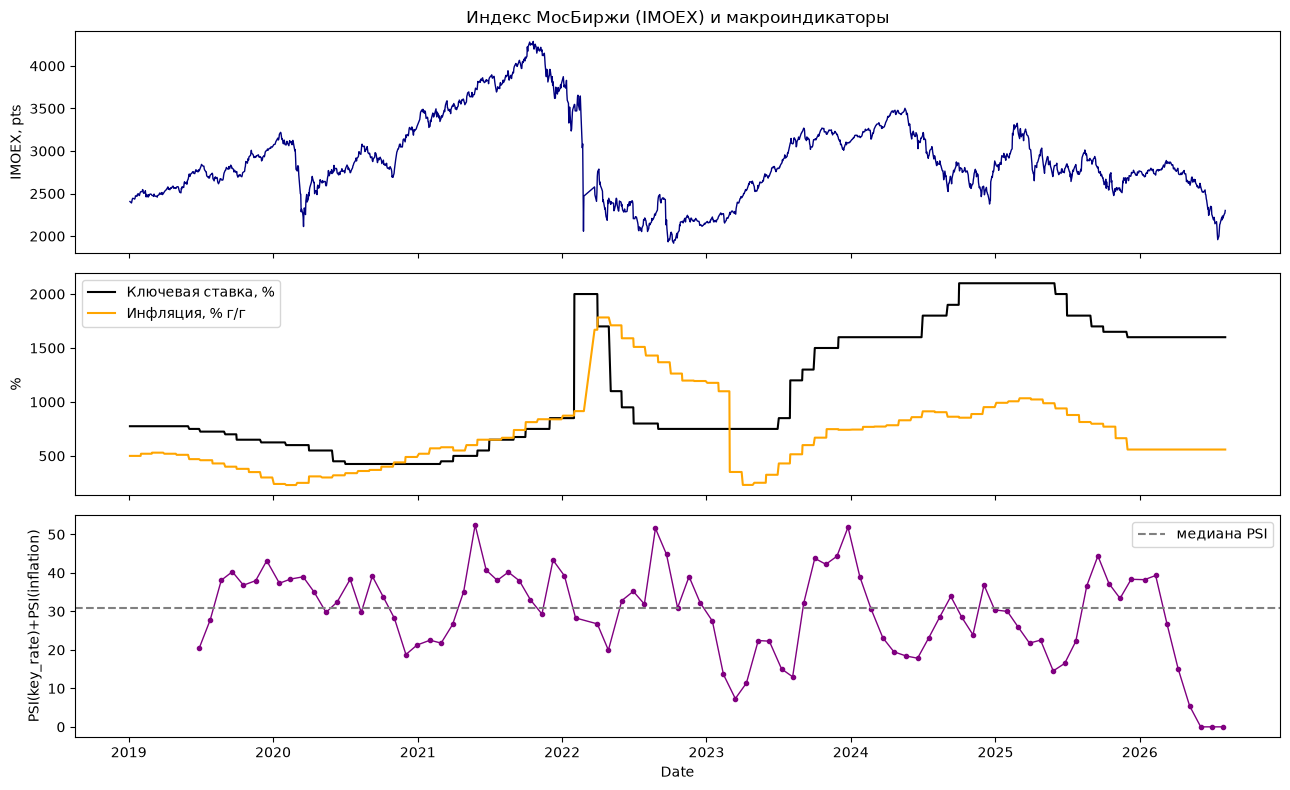

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)

axes[0].plot(df_raw.index, df_raw["close"], color="navy", linewidth=1)
axes[0].set_ylabel("IMOEX, pts")
axes[0].set_title("Индекс МосБиржи (IMOEX) и макроиндикаторы")

axes[1].plot(df_raw.index, df_raw["key_rate"] * 100, color="black", label="Ключевая ставка, %")
axes[1].plot(df_raw.index, df_raw["inflation"] * 100, color="orange", label="Инфляция, % г/г")
axes[1].set_ylabel("%")
axes[1].legend(loc="upper left")

axes[2].plot(drift_series.index, drift_series.values, marker="o", markersize=3, linewidth=1, color="purple")
axes[2].axhline(drift_series.median(), linestyle="--", color="gray", label="медиана PSI")
axes[2].set_ylabel("PSI(key_rate)+PSI(inflation)")
axes[2].set_xlabel("Date")
axes[2].legend()

plt.tight_layout()
plt.savefig("../graphics/market_and_drift_overview.png", dpi=120)
plt.show()

### Regime Split: NoDrift vs WithDrift

Выборка разбивается по PSI-метрике дрейфа на два поднабора: `NoDrift` (нижние 40% по PSI — относительно стабильные участки истории) и `WithDrift` (верхние 40% по PSI — участки, примыкающие к сменам режима ключевой ставки). Далее эти два поднабора используются везде вместо `Circles`/`Moons` из предыдущей статьи, а базовыми признаками для кодирования служат **ключевая ставка ЦБ РФ и инфляция** — ровно те макроиндикаторы, сравнение кодирования которых требуется по заданию.

In [14]:
q40 = df_features["drift_score"].quantile(0.4)
q60 = df_features["drift_score"].quantile(0.6)

no_drift_df = df_features[df_features["drift_score"] <= q40]
with_drift_df = df_features[df_features["drift_score"] >= q60]

print("NoDrift:", no_drift_df.shape, "mean PSI =", no_drift_df["drift_score"].mean())
print("WithDrift:", with_drift_df.shape, "mean PSI =", with_drift_df["drift_score"].mean())

N_SAMPLE = 300
regime_frames = {"NoDrift": no_drift_df, "WithDrift": with_drift_df}
regime_data = {}

for regime_name, sub in regime_frames.items():
    sub = sub.sample(n=min(N_SAMPLE, len(sub)), random_state=42).sort_index()

    X_base = sub[["key_rate", "inflation"]].values
    y = sub["y_high_vol"].values

    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X_base, y, test_size=0.3, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_raw)
    X_test = scaler.transform(X_test_raw)

    regime_data[regime_name] = {
        "X_train": X_train, "X_test": X_test,
        "y_train": y_train, "y_test": y_test,
        "drift_local_mean": sub["drift_score"].mean()
    }

X_NoDrift_train, X_NoDrift_test = regime_data["NoDrift"]["X_train"], regime_data["NoDrift"]["X_test"]
y_NoDrift_train, y_NoDrift_test = regime_data["NoDrift"]["y_train"], regime_data["NoDrift"]["y_test"]

X_WithDrift_train, X_WithDrift_test = regime_data["WithDrift"]["X_train"], regime_data["WithDrift"]["X_test"]
y_WithDrift_train, y_WithDrift_test = regime_data["WithDrift"]["y_train"], regime_data["WithDrift"]["y_test"]

NoDrift: (762, 12) mean PSI = 18.353270453585452
WithDrift: (760, 12) mean PSI = 39.83695333808655


### Variational Quantum Classifiers

Как и в прошлой статье, наивный базовый эксперимент подаёт на вход всего 2 признака (`key_rate`, `inflation`) независимо от числа кубитов — `AngleEmbedding` при нехватке признаков просто не поворачивает лишние кубиты. Это демонстрирует деградацию качества "по умолчанию", ещё до того как вводится осмысленное расширение признаков (см. раздел "Feature Preparation for Quantum Circuits").

**NoDrift**

In [15]:
qubits = [2, 4, 8]

for q in qubits:
    vqc_no_drift = VQC(n_qubits=q, encoding="angle")

    losses = vqc_no_drift.fit(X_NoDrift_train, y_NoDrift_train)

    grads, grad_norm, grad_var = compute_gradients(vqc_no_drift, X_NoDrift_train, y_NoDrift_train)
    grad_mean = grads.mean()

    results.append({
        "Model": "VQC",
        "Dataset": "NoDrift",
        "n_qubits": q,
        "Hidden_Layers": None,
        "Loss_final": losses[-1],
        "Gradient_Norm": grad_norm,
        "Gradient_Variance": grad_var,
        "Gradient_Mean": grad_mean
    })

**WithDrift**

In [16]:
qubits = [2, 4, 8]

for q in qubits:
    vqc_with_drift = VQC(n_qubits=q, encoding="angle")

    losses = vqc_with_drift.fit(X_WithDrift_train, y_WithDrift_train)

    grads, grad_norm, grad_var = compute_gradients(vqc_with_drift, X_WithDrift_train, y_WithDrift_train)
    grad_mean = grads.mean()

    results.append({
        "Model": "VQC",
        "Dataset": "WithDrift",
        "n_qubits": q,
        "Hidden_Layers": None,
        "Loss_final": losses[-1],
        "Gradient_Norm": grad_norm,
        "Gradient_Variance": grad_var,
        "Gradient_Mean": grad_mean
    })

### Hybrid Variational Quantum Classifiers

**NoDrift**

In [17]:
qubits = [2, 4, 8]

for q in qubits:
    vqc_hybrid_no_drift = VQC_hybrid(n_qubits=q, encoding="angle")

    losses = vqc_hybrid_no_drift.fit(X_NoDrift_train, y_NoDrift_train)

    grads, grad_norm, grad_var = compute_gradients(vqc_hybrid_no_drift, X_NoDrift_train, y_NoDrift_train)
    grad_mean = grads.mean()

    results.append({
        "Model": "VQC_hybrid",
        "Dataset": "NoDrift",
        "n_qubits": q,
        "Hidden_Layers": None,
        "Loss_final": losses[-1],
        "Gradient_Norm": grad_norm,
        "Gradient_Variance": grad_var,
        "Gradient_Mean": grad_mean
    })

**WithDrift**

In [18]:
qubits = [2, 4, 8]

for q in qubits:
    vqc_hybrid_with_drift = VQC_hybrid(n_qubits=q, encoding="angle")

    losses = vqc_hybrid_with_drift.fit(X_WithDrift_train, y_WithDrift_train)

    grads, grad_norm, grad_var = compute_gradients(vqc_hybrid_with_drift, X_WithDrift_train, y_WithDrift_train)
    grad_mean = grads.mean()

    results.append({
        "Model": "VQC_hybrid",
        "Dataset": "WithDrift",
        "n_qubits": q,
        "Hidden_Layers": None,
        "Loss_final": losses[-1],
        "Gradient_Norm": grad_norm,
        "Gradient_Variance": grad_var,
        "Gradient_Mean": grad_mean
    })

### MLP

**NoDrift**

In [19]:
mlp_configs = [
    [8, 8],      # 2 слоя по 8 нейронов
    [16, 16],    # 2 слоя по 16 нейронов
    [32, 32]     # 2 слоя по 32 нейронов
]


for config in mlp_configs:
    mlp_no_drift = MLPClassifier(hidden_layer_sizes=tuple(config), max_iter=150, random_state=42)
    mlp_no_drift.fit(X_NoDrift_train, y_NoDrift_train)

    y_pred = mlp_no_drift.predict(X_NoDrift_test)

    results.append({
        "Model": "MLP",
        "Dataset": "NoDrift",
        "n_qubits": None,
        "Hidden_Layers": str(config),
        "Loss_final": mlp_no_drift.loss_,
        "Gradient_Norm": None,
        "Gradient_Variance": None,
        "Gradient_Mean": None
    })

/Users/egorsipilov/Documents/VScode_proj/Barren-Plateau-Volatility/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/egorsipilov/Documents/VScode_proj/Barren-Plateau-Volatility/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


**WithDrift**

In [20]:
mlp_configs = [
    [8, 8],      # 2 слоя по 8 нейронов
    [16, 16],    # 2 слоя по 16 нейронов
    [32, 32]     # 2 слоя по 32 нейронов
]


for config in mlp_configs:
    mlp_with_drift = MLPClassifier(hidden_layer_sizes=tuple(config), max_iter=150, random_state=42)
    mlp_with_drift.fit(X_WithDrift_train, y_WithDrift_train)

    y_pred = mlp_with_drift.predict(X_WithDrift_test)

    results.append({
        "Model": "MLP",
        "Dataset": "WithDrift",
        "n_qubits": None,
        "Hidden_Layers": str(config),
        "Loss_final": mlp_with_drift.loss_,
        "Gradient_Norm": None,
        "Gradient_Variance": None,
        "Gradient_Mean": None
    })

/Users/egorsipilov/Documents/VScode_proj/Barren-Plateau-Volatility/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/egorsipilov/Documents/VScode_proj/Barren-Plateau-Volatility/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/egorsipilov/Documents/VScode_proj/Barren-Plateau-Volatility/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


### Analysis of the results

In [21]:
df_results = pd.DataFrame(results)

df_results = df_results.sort_values(
    by=["Dataset"]
)

df_results

,Model,Dataset,n_qubits,Hidden_Layers,Loss_final,Gradient_Norm,Gradient_Variance,Gradient_Mean
0,VQC,NoDrift,2.0,NaN,0.619389,0.000015,1.951566e-11,7.376568e-07
14,MLP,NoDrift,NaN,"[32, 32]",0.586937,NaN,NaN,NaN
13,MLP,NoDrift,NaN,"[16, 16]",0.610112,NaN,NaN,NaN
12,MLP,NoDrift,NaN,"[8, 8]",0.640746,NaN,NaN,NaN
7,VQC_hybrid,NoDrift,4.0,NaN,0.561246,0.035055,3.064317e-05,2.759600e-04
6,VQC_hybrid,NoDrift,2.0,NaN,0.564688,0.024750,3.026031e-05,-5.916069e-04
8,VQC_hybrid,NoDrift,8.0,NaN,0.559611,0.003075,1.169857e-07,3.491210e-05
2,VQC,NoDrift,8.0,NaN,0.638090,0.000022,9.994673e-12,-3.956104e-07
1,VQC,NoDrift,4.0,NaN,0.638491,0.000060,1.529162e-10,-2.359524e-06
4,VQC,WithDrift,4.0,NaN,0.623977,0.000042,7.161276e-11,2.091448e-06


### Additional Diagnostics for Barren Plateaus

На предыдущем этапе были обучены базовые модели `VQC`, `VQC_hybrid` и `MLP`, а также сохранены итоговые значения функции потерь и градиентов. Однако для анализа Barren Plateaus недостаточно смотреть только на финальную норму градиента. Необходимо отслеживать динамику обучения по эпохам: изменение функции потерь, нормы градиента и дисперсии градиента.

Проблема Barren Plateaus проявляется в том, что градиенты параметров вариационной квантовой схемы становятся исчезающе малыми при росте числа кубитов, из-за чего оптимизация практически останавливается.

### Feature Preparation for Quantum Circuits

Исходные признаки `key_rate` и `inflation` — только два макроиндикатора. При этом в эксперименте используются квантовые схемы с 2, 4 и 8 кубитами. Если число признаков меньше числа кубитов, часть кубитов не получает содержательного входного сигнала. Это может дополнительно ухудшать обучение и усиливать эффект деградации при увеличении числа кубитов.

Поэтому добавим отдельную функцию подготовки признаков. Она расширяет двумерное пространство (`key_rate`, `inflation`) до нужного числа кубитов с помощью нелинейных преобразований — точно так же, как в предыдущей статье расширялись координаты `Circles`/`Moons`.

In [22]:
def expand_features_for_qubits(X, n_qubits):
    x1 = X[:, 0]  # key_rate (standardized)
    x2 = X[:, 1]  # inflation (standardized)

    features = [
        x1,
        x2,
        x1 ** 2,
        x2 ** 2,
        x1 * x2,
        np.sqrt(x1 ** 2 + x2 ** 2),
        np.sin(x1),
        np.cos(x1),
        np.sin(x2),
        np.cos(x2)
    ]

    X_new = np.column_stack(features)

    if X_new.shape[1] < n_qubits:
        repeat_count = int(np.ceil(n_qubits / X_new.shape[1]))
        X_new = np.tile(X_new, (1, repeat_count))

    return X_new[:, :n_qubits]


def prepare_quantum_features(X_train, X_test, n_qubits):
    X_train_expanded = expand_features_for_qubits(X_train, n_qubits)
    X_test_expanded = expand_features_for_qubits(X_test, n_qubits)

    scaler = MinMaxScaler(feature_range=(-np.pi, np.pi))

    X_train_scaled = scaler.fit_transform(X_train_expanded)
    X_test_scaled = scaler.transform(X_test_expanded)

    return X_train_scaled, X_test_scaled

### Gradient Logging During Training

В старой реализации метод `fit` возвращает только значения функции потерь. Для анализа Barren Plateaus добавим отдельную функцию обучения, которая не меняет классы `VQC`, `VQC_hybrid` и `VQCAnsatz`, но позволяет сохранить расширенную информацию о градиентах.

Будем логировать следующие величины:

$$
\|\nabla C(\theta)\|_2 = \sqrt{\sum_{i=1}^{m}\left(\frac{\partial C(\theta)}{\partial \theta_i}\right)^2}
$$

где:

- $\|\nabla C(\theta)\|_2$ — евклидова норма градиента;
- $C(\theta)$ — функция потерь;
- $\theta_i$ — параметры квантовой схемы;
- $m$ — общее число параметров.

In [23]:
def get_grad_stats(model):
    grads = []

    for param in model.parameters():
        if param.grad is not None:
            grads.append(param.grad.detach().flatten())

    if len(grads) == 0:
        return {
            "grad_norm": 0.0,
            "grad_var": 0.0,
            "grad_mean_abs": 0.0,
            "grad_max_abs": 0.0
        }

    grads = torch.cat(grads)

    return {
        "grad_norm": torch.norm(grads).item(),
        "grad_var": torch.var(grads).item(),
        "grad_mean_abs": torch.mean(torch.abs(grads)).item(),
        "grad_max_abs": torch.max(torch.abs(grads)).item()
    }


def fit_with_gradient_logging(model, X_train, y_train, epochs=150, lr=0.1, optimizer_name="adam"):
    if optimizer_name == "adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name == "sgd":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    else:
        raise ValueError("optimizer_name must be 'adam' or 'sgd'")

    loss_fn = torch.nn.BCELoss()

    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.float32)

    history = {
        "loss": [],
        "grad_norm": [],
        "grad_var": [],
        "grad_mean_abs": [],
        "grad_max_abs": []
    }

    model.train()

    for epoch in range(epochs):
        optimizer.zero_grad()

        preds = model(X_train_t).squeeze()
        loss = loss_fn(preds, y_train_t)

        loss.backward()

        grad_stats = get_grad_stats(model)

        optimizer.step()

        history["loss"].append(loss.item())
        history["grad_norm"].append(grad_stats["grad_norm"])
        history["grad_var"].append(grad_stats["grad_var"])
        history["grad_mean_abs"].append(grad_stats["grad_mean_abs"])
        history["grad_max_abs"].append(grad_stats["grad_max_abs"])

        if epoch % 50 == 0:
            print(
                f"Epoch {epoch:03d} | "
                f"loss={loss.item():.5f} | "
                f"grad_norm={grad_stats['grad_norm']:.3e} | "
                f"grad_var={grad_stats['grad_var']:.3e}"
            )

    return history

### Training Dynamics Visualization

Для диагностики Barren Plateaus построим три основных графика:

1. график функции потерь по эпохам;
2. график нормы градиента по эпохам;
3. график дисперсии градиента по эпохам.

Если модель попадает в Barren Plateau, то функция потерь выходит на плато, а значения нормы и дисперсии градиента падают до очень малых величин.

In [24]:
def plot_barren_plateau_diagnostics(history, title):
    epochs = np.arange(1, len(history["loss"]) + 1)

    plt.figure(figsize=(14, 4))

    plt.subplot(1, 3, 1)
    plt.plot(epochs, history["loss"], linewidth=2)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss dynamics")
    plt.grid(alpha=0.3)

    plt.subplot(1, 3, 2)
    plt.plot(epochs, history["grad_norm"], linewidth=2)
    plt.xlabel("Epoch")
    plt.ylabel("Gradient norm")
    plt.yscale("log")
    plt.title("Gradient norm dynamics")
    plt.grid(alpha=0.3)

    plt.subplot(1, 3, 3)
    plt.plot(epochs, history["grad_var"], linewidth=2)
    plt.xlabel("Epoch")
    plt.ylabel("Gradient variance")
    plt.yscale("log")
    plt.title("Gradient variance dynamics")
    plt.grid(alpha=0.3)

    plt.suptitle(title)
    plt.tight_layout()
    plt.savefig(f"../graphics/diag_{title.replace(' ', '_').replace(':', '').replace(',', '')}.png", dpi=120)
    plt.show()

### Baseline VQC Diagnostics

Теперь повторим обучение базовой квантовой модели `VQC`, но уже с логированием градиентов по эпохам, и с корректным расширением признаков через `prepare_quantum_features`. Это не заменяет старый эксперимент, а добавляет к нему диагностический слой.

Особое внимание уделяется сравнению схем при $n = 2$, $n = 4$ и $n = 8$, где $n$ — число кубитов, на обоих режимах дрейфа: `NoDrift` и `WithDrift`.


Dataset: NoDrift | Model: VQC | Qubits: 2
Epoch 000 | loss=0.70878 | grad_norm=1.568e-01 | grad_var=2.211e-03
Epoch 050 | loss=0.61277 | grad_norm=2.745e-03 | grad_var=5.963e-07
Epoch 100 | loss=0.61266 | grad_norm=2.509e-04 | grad_var=4.932e-09


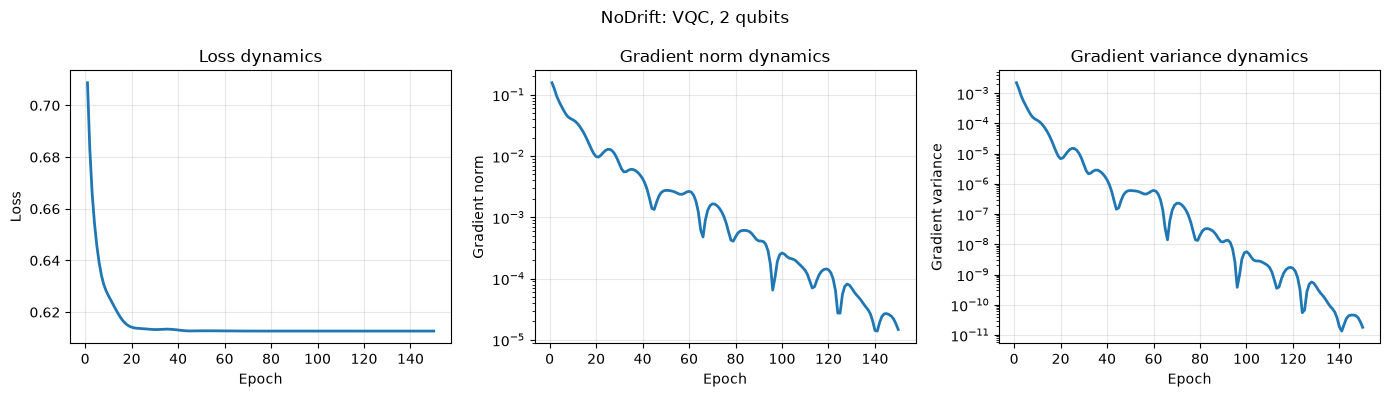


Dataset: NoDrift | Model: VQC | Qubits: 4
Epoch 000 | loss=0.68285 | grad_norm=4.432e-02 | grad_var=8.341e-05
Epoch 050 | loss=0.62802 | grad_norm=3.949e-03 | grad_var=6.650e-07
Epoch 100 | loss=0.62783 | grad_norm=2.348e-04 | grad_var=2.361e-09


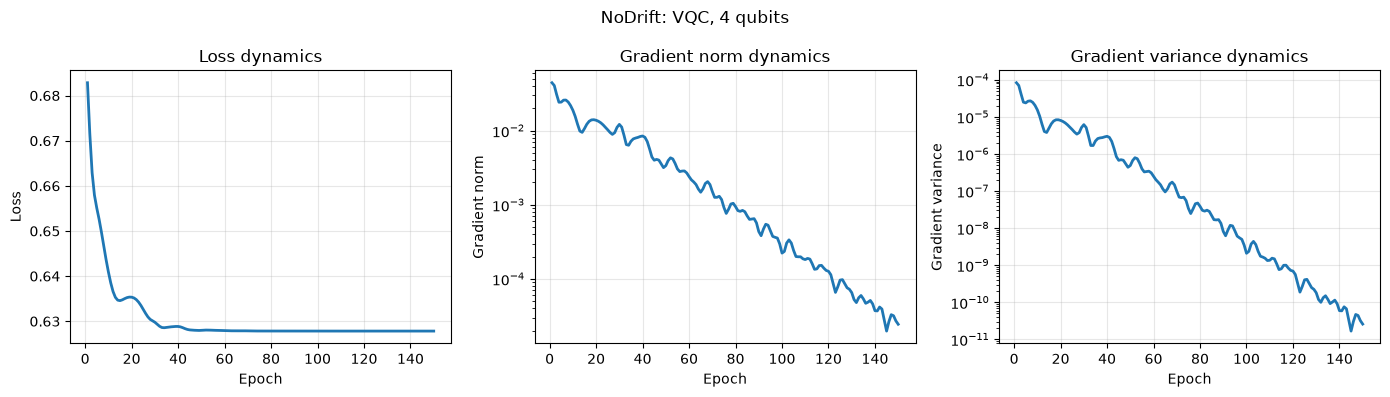


Dataset: NoDrift | Model: VQC | Qubits: 8
Epoch 000 | loss=0.69322 | grad_norm=1.651e-02 | grad_var=5.793e-06
Epoch 050 | loss=0.62710 | grad_norm=3.346e-03 | grad_var=2.369e-07
Epoch 100 | loss=0.62685 | grad_norm=1.998e-04 | grad_var=8.127e-10


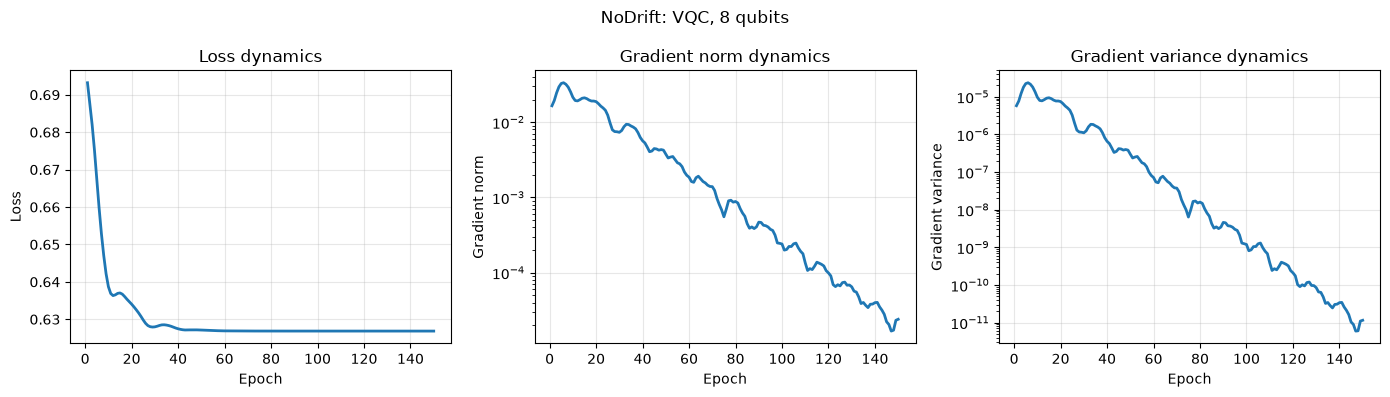


Dataset: WithDrift | Model: VQC | Qubits: 2
Epoch 000 | loss=0.69728 | grad_norm=4.501e-02 | grad_var=1.805e-04
Epoch 050 | loss=0.65235 | grad_norm=5.442e-03 | grad_var=2.693e-06
Epoch 100 | loss=0.65202 | grad_norm=4.803e-04 | grad_var=2.097e-08


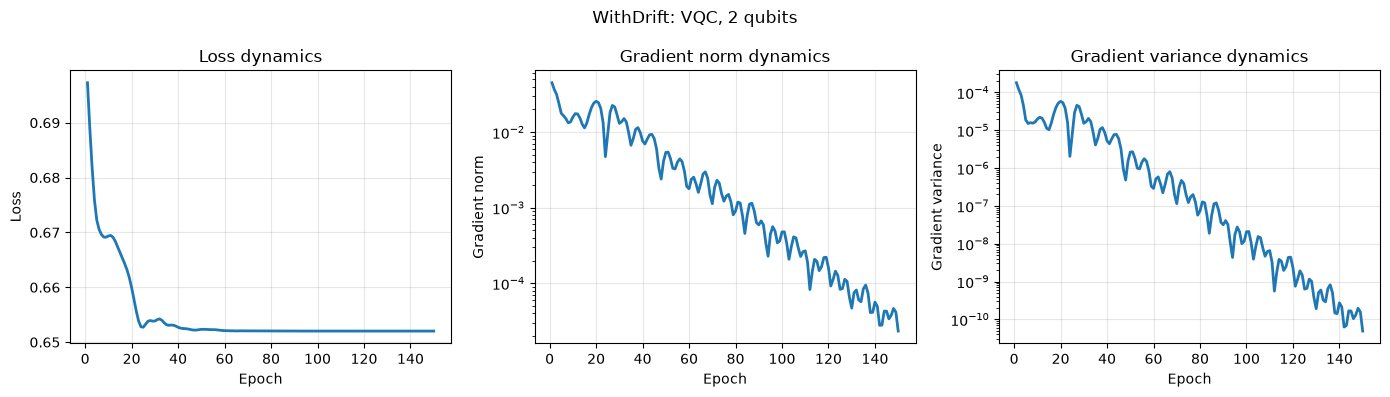


Dataset: WithDrift | Model: VQC | Qubits: 4
Epoch 000 | loss=0.70269 | grad_norm=6.636e-02 | grad_var=1.889e-04
Epoch 050 | loss=0.60104 | grad_norm=7.685e-03 | grad_var=2.557e-06
Epoch 100 | loss=0.60009 | grad_norm=7.106e-04 | grad_var=2.014e-08


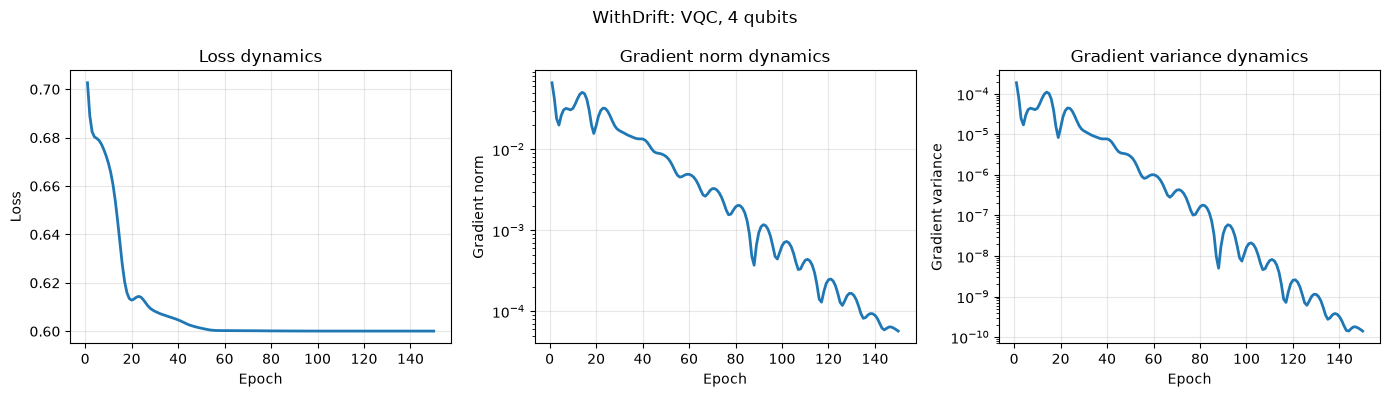


Dataset: WithDrift | Model: VQC | Qubits: 8
Epoch 000 | loss=0.69458 | grad_norm=2.331e-02 | grad_var=1.156e-05
Epoch 050 | loss=0.60810 | grad_norm=5.939e-03 | grad_var=7.419e-07
Epoch 100 | loss=0.60769 | grad_norm=4.627e-04 | grad_var=4.214e-09


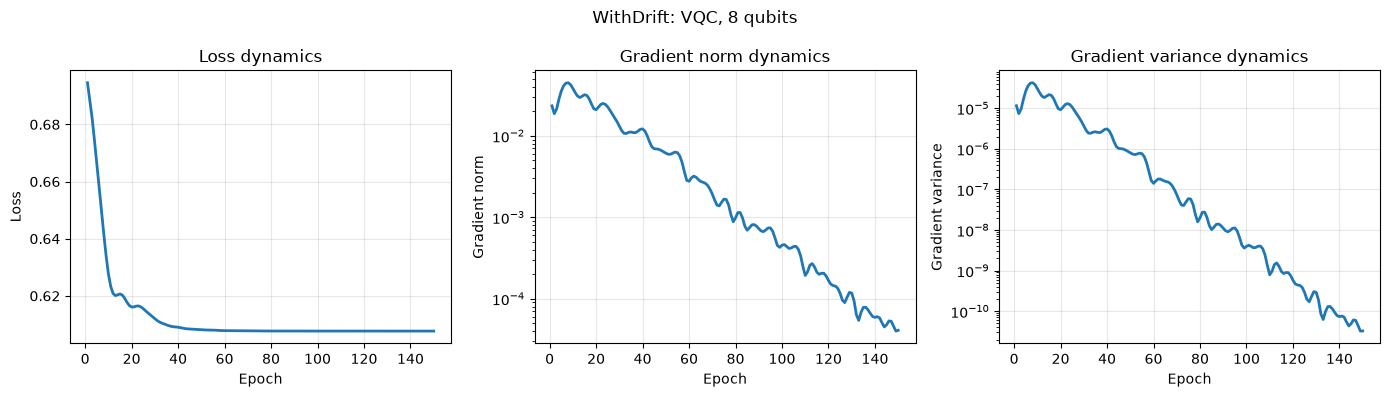

In [25]:
diagnostic_results = []
diagnostic_histories = {}

for dataset_name, X_train, X_test, y_train, y_test in [
    ("NoDrift", X_NoDrift_train, X_NoDrift_test, y_NoDrift_train, y_NoDrift_test),
    ("WithDrift", X_WithDrift_train, X_WithDrift_test, y_WithDrift_train, y_WithDrift_test)
]:
    for q in [2, 4, 8]:
        print(f"\nDataset: {dataset_name} | Model: VQC | Qubits: {q}")

        X_train_q, X_test_q = prepare_quantum_features(X_train, X_test, q)

        model = VQC(n_qubits=q, encoding="angle")

        history = fit_with_gradient_logging(
            model,
            X_train_q,
            y_train,
            epochs=150,
            lr=0.1,
            optimizer_name="adam"
        )

        y_pred = model(torch.tensor(X_test_q, dtype=torch.float32)).detach().numpy()
        y_pred = (y_pred > 0.5).astype(int)

        diagnostic_results.append({
            "Dataset": dataset_name,
            "Model": "VQC_diagnostic",
            "n_qubits": q,
            "Final_Loss": history["loss"][-1],
            "Mean_Last20_Grad_Norm": np.mean(history["grad_norm"][-20:]),
            "Mean_Last20_Grad_Var": np.mean(history["grad_var"][-20:]),
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred, zero_division=0),
            "Recall": recall_score(y_test, y_pred, zero_division=0),
            "F1": f1_score(y_test, y_pred, zero_division=0)
        })

        key = f"{dataset_name}_VQC_{q}"
        diagnostic_histories[key] = history

        plot_barren_plateau_diagnostics(
            history,
            title=f"{dataset_name}: VQC, {q} qubits"
        )

In [26]:
diagnostic_df = pd.DataFrame(diagnostic_results)
diagnostic_df

,Dataset,Model,n_qubits,Final_Loss,Mean_Last20_Grad_Norm,Mean_Last20_Grad_Var,Accuracy,Precision,Recall,F1
0,NoDrift,VQC_diagnostic,2,0.612662,0.000030,8.029411e-11,0.644444,0.615385,0.727273,0.666667
1,NoDrift,VQC_diagnostic,4,0.627826,0.000040,7.561000e-11,0.577778,0.562500,0.613636,0.586957
2,NoDrift,VQC_diagnostic,8,0.626849,0.000034,2.724204e-11,0.633333,0.600000,0.750000,0.666667
3,WithDrift,VQC_diagnostic,2,0.652020,0.000052,2.778870e-10,0.644444,0.684211,0.333333,0.448276
4,WithDrift,VQC_diagnostic,4,0.600076,0.000084,3.184983e-10,0.655556,0.722222,0.333333,0.456140
5,WithDrift,VQC_diagnostic,8,0.607685,0.000060,7.880418e-11,0.655556,0.653846,0.435897,0.523077


### Gradient Scaling with the Number of Qubits

Следующий график показывает, как средняя норма градиента за последние эпохи меняется при увеличении числа кубитов.

Для Barren Plateaus характерно экспоненциальное уменьшение дисперсии градиента с ростом числа кубитов. В упрощённом виде это можно записать так:

$$
\mathrm{Var}\left[\frac{\partial C(\theta)}{\partial \theta_i}\right] \sim \mathcal{O}\left(\frac{1}{2^n}\right)
$$

где:

- $\mathrm{Var}\left[\frac{\partial C(\theta)}{\partial \theta_i}\right]$ — дисперсия градиента по параметру $\theta_i$;
- $n$ — число кубитов.

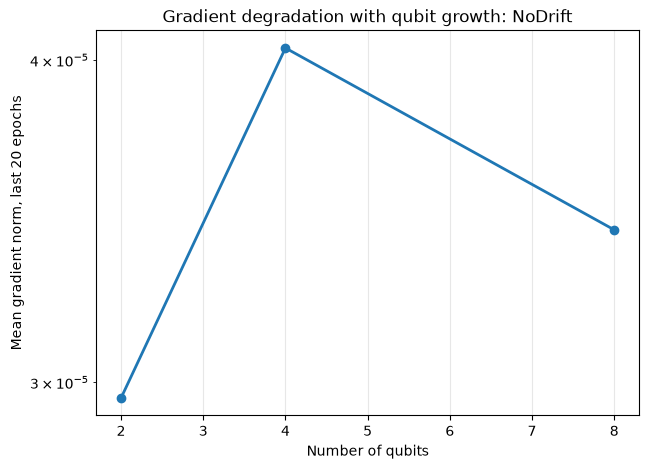

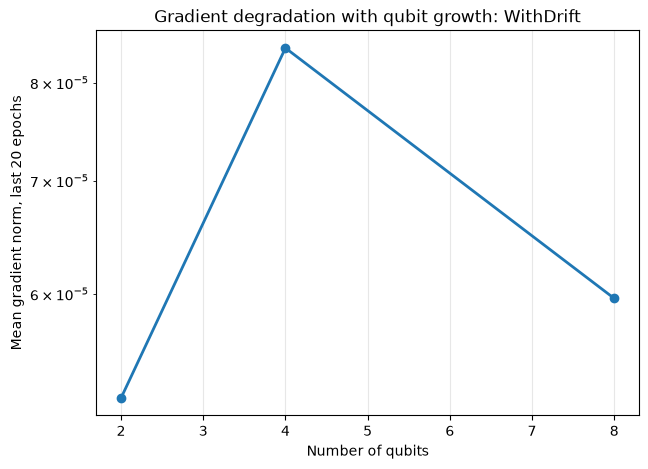

In [27]:
def plot_gradient_vs_qubits(df, dataset_name):
    part = df[df["Dataset"] == dataset_name].sort_values("n_qubits")

    plt.figure(figsize=(7, 5))
    plt.plot(
        part["n_qubits"],
        part["Mean_Last20_Grad_Norm"],
        marker="o",
        linewidth=2
    )
    plt.yscale("log")
    plt.xlabel("Number of qubits")
    plt.ylabel("Mean gradient norm, last 20 epochs")
    plt.title(f"Gradient degradation with qubit growth: {dataset_name}")
    plt.grid(alpha=0.3)
    plt.savefig(f"../graphics/grad_vs_qubits_{dataset_name}.png", dpi=120)
    plt.show()


plot_gradient_vs_qubits(diagnostic_df, "NoDrift")
plot_gradient_vs_qubits(diagnostic_df, "WithDrift")

### Alternative Ansatz Architectures

Исходная модель использует `StronglyEntanglingLayers`. Такой Ansatz является выразительным, но при увеличении числа кубитов и глубины схемы может приводить к слишком сложному ландшафту оптимизации.

Поэтому добавим альтернативные схемы, не изменяя старые классы `VQC` и `VQC_hybrid`. Будут рассмотрены три варианта Ansatz:

1. `strong` — схема на основе `StronglyEntanglingLayers`;
2. `basic` — более простая схема на основе `BasicEntanglerLayers`;
3. `ry_cz` — ручная схема с чередованием `RY` и `CZ`.

По сравнению с прошлой статьёй `VQCAnsatz` также получает параметр `encoding` (`angle` / `iqp`) — это тот же класс, который используется далее и в сравнении кодирований, и в адаптивной пересборке схемы.

In [28]:
class VQCAnsatz(nn.Module):
    def __init__(self, n_qubits=2, n_layers=2, ansatz_type="basic", encoding="angle", dev_name="default.qubit", init_scale=0.01):
        super(VQCAnsatz, self).__init__()

        self.n_qubits = n_qubits
        self.n_layers = n_layers
        self.ansatz_type = ansatz_type
        self.encoding = encoding
        self.dev = qml.device(dev_name, wires=n_qubits)

        def embed(inputs):
            if encoding == "angle":
                qml.AngleEmbedding(inputs, wires=range(n_qubits))
            elif encoding == "iqp":
                qml.IQPEmbedding(inputs, wires=range(n_qubits), n_repeats=2)
            else:
                raise ValueError("encoding must be 'angle' or 'iqp'")

        if ansatz_type == "strong":
            weight_shapes = {"weights": (n_layers, n_qubits, 3)}

            @qml.qnode(self.dev, interface="torch")
            def quantum_circuit(inputs, weights):
                embed(inputs)
                qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
                return qml.expval(qml.PauliZ(0))

        elif ansatz_type == "basic":
            weight_shapes = {"weights": (n_layers, n_qubits)}

            @qml.qnode(self.dev, interface="torch")
            def quantum_circuit(inputs, weights):
                embed(inputs)
                qml.BasicEntanglerLayers(weights, wires=range(n_qubits))
                return qml.expval(qml.PauliZ(0))

        elif ansatz_type == "ry_cz":
            weight_shapes = {"weights": (n_layers, n_qubits)}

            @qml.qnode(self.dev, interface="torch")
            def quantum_circuit(inputs, weights):
                embed(inputs)

                for layer in range(n_layers):
                    for wire in range(n_qubits):
                        qml.RY(weights[layer, wire], wires=wire)

                    for wire in range(n_qubits - 1):
                        qml.CZ(wires=[wire, wire + 1])

                return qml.expval(qml.PauliZ(0))

        else:
            raise ValueError("ansatz_type must be 'strong', 'basic' or 'ry_cz'")

        self.quantum_layer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)

        with torch.no_grad():
            for param in self.quantum_layer.parameters():
                param.normal_(mean=0.0, std=init_scale)

        self.model = nn.Sequential(
            self.quantum_layer,
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x).squeeze()

### Ansatz Comparison

Теперь сравним несколько вариантов квантовой схемы при одинаковом числе кубитов на обоих режимах дрейфа. Это позволит проверить гипотезу: более простые схемы могут обучаться стабильнее, потому что реже попадают в область исчезающих градиентов.

Для бинарной классификации выход модели можно интерпретировать как вероятность принадлежности к положительному классу:

$$
\hat{y} = \sigma(z)
$$

где:

- $\hat{y}$ — предсказанная вероятность класса 1 (`y_high_vol = 1`, повышенная волатильность MOEX на горизонте 5 дней);
- $\sigma$ — сигмоидная функция;
- $z$ — выход квантовой схемы (математическое ожидание оператора Паули $Z$ на первом кубите).

In [29]:
ansatz_results = []
ansatz_histories = {}

for dataset_name, X_train, X_test, y_train, y_test in [
    ("NoDrift", X_NoDrift_train, X_NoDrift_test, y_NoDrift_train, y_NoDrift_test),
    ("WithDrift", X_WithDrift_train, X_WithDrift_test, y_WithDrift_train, y_WithDrift_test)
]:
    for q in [2, 4, 8]:
        X_train_q, X_test_q = prepare_quantum_features(X_train, X_test, q)

        for ansatz_type in ["ry_cz", "basic", "strong"]:
            print(f"\nDataset: {dataset_name} | Ansatz: {ansatz_type} | Qubits: {q}")

            model = VQCAnsatz(
                n_qubits=q,
                n_layers=2,
                ansatz_type=ansatz_type,
                encoding="angle",
                init_scale=0.01
            )

            history = fit_with_gradient_logging(
                model,
                X_train_q,
                y_train,
                epochs=150,
                lr=0.05,
                optimizer_name="adam"
            )

            y_pred = model(torch.tensor(X_test_q, dtype=torch.float32)).detach().numpy()
            y_pred = (y_pred > 0.5).astype(int)

            ansatz_results.append({
                "Dataset": dataset_name,
                "Ansatz": ansatz_type,
                "n_qubits": q,
                "Final_Loss": history["loss"][-1],
                "Mean_Last20_Grad_Norm": np.mean(history["grad_norm"][-20:]),
                "Mean_Last20_Grad_Var": np.mean(history["grad_var"][-20:]),
                "Accuracy": accuracy_score(y_test, y_pred),
                "Precision": precision_score(y_test, y_pred, zero_division=0),
                "Recall": recall_score(y_test, y_pred, zero_division=0),
                "F1": f1_score(y_test, y_pred, zero_division=0)
            })

            key = f"{dataset_name}_{ansatz_type}_{q}"
            ansatz_histories[key] = history


Dataset: NoDrift | Ansatz: ry_cz | Qubits: 2
Epoch 000 | loss=0.76907 | grad_norm=1.820e-03 | grad_var=5.523e-07
Epoch 050 | loss=0.63512 | grad_norm=1.027e-02 | grad_var=1.768e-05
Epoch 100 | loss=0.63417 | grad_norm=8.717e-04 | grad_var=1.262e-07

Dataset: NoDrift | Ansatz: basic | Qubits: 2
Epoch 000 | loss=0.76806 | grad_norm=5.477e-02 | grad_var=7.455e-04
Epoch 050 | loss=0.65322 | grad_norm=2.215e-02 | grad_var=1.558e-04
Epoch 100 | loss=0.64667 | grad_norm=9.097e-04 | grad_var=1.595e-07

Dataset: NoDrift | Ansatz: strong | Qubits: 2
Epoch 000 | loss=0.79784 | grad_norm=3.142e-03 | grad_var=8.925e-07
Epoch 050 | loss=0.61407 | grad_norm=1.125e-02 | grad_var=9.816e-06
Epoch 100 | loss=0.61267 | grad_norm=6.253e-04 | grad_var=3.428e-08

Dataset: NoDrift | Ansatz: ry_cz | Qubits: 4
Epoch 000 | loss=0.76907 | grad_norm=4.898e-05 | grad_var=2.678e-10
Epoch 050 | loss=0.63513 | grad_norm=1.034e-02 | grad_var=1.144e-05
Epoch 100 | loss=0.63417 | grad_norm=8.863e-04 | grad_var=8.400e-08

In [30]:
ansatz_df = pd.DataFrame(ansatz_results)
ansatz_df

,Dataset,Ansatz,n_qubits,Final_Loss,Mean_Last20_Grad_Norm,Mean_Last20_Grad_Var,Accuracy,Precision,Recall,F1
0,NoDrift,ry_cz,2,0.634161,0.000088,1.930730e-09,0.633333,0.627907,0.613636,0.620690
1,NoDrift,basic,2,0.646616,0.000446,4.393829e-08,0.655556,0.614035,0.795455,0.693069
2,NoDrift,strong,2,0.612665,0.000130,1.280695e-09,0.644444,0.615385,0.727273,0.666667
3,NoDrift,ry_cz,4,0.634161,0.000145,2.817493e-09,0.633333,0.627907,0.613636,0.620690
4,NoDrift,basic,4,0.622126,0.000014,3.112239e-11,0.655556,0.675676,0.568182,0.617284
5,NoDrift,strong,4,0.627826,0.000095,4.235278e-10,0.577778,0.562500,0.613636,0.586957
6,NoDrift,ry_cz,8,0.634164,0.000959,6.552317e-08,0.633333,0.627907,0.613636,0.620690
7,NoDrift,basic,8,0.638905,0.000281,5.929973e-09,0.666667,0.634615,0.750000,0.687500
8,NoDrift,strong,8,0.627858,0.000116,3.101320e-10,0.522222,0.516129,0.363636,0.426667
9,WithDrift,ry_cz,2,0.678331,0.000217,1.484010e-08,0.466667,0.333333,0.230769,0.272727


### Ansatz Gradient Comparison

Если `StronglyEntanglingLayers` демонстрирует более быстрое падение нормы градиента при росте числа кубитов, это подтверждает предположение о том, что слишком выразительный Ansatz может ухудшать обучаемость модели.

В данном эксперименте основной диагностической величиной является средняя норма градиента за последние эпохи:

$$
G_{\text{last}} = \frac{1}{K}\sum_{t=T-K+1}^{T}\|\nabla C_t(\theta)\|_2
$$

где:

- $G_{\text{last}}$ — средняя норма градиента на последних $K$ эпохах;
- $T$ — общее число эпох обучения.

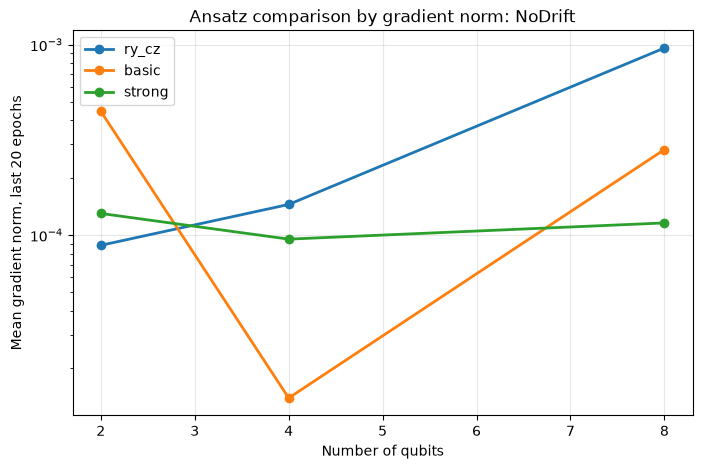

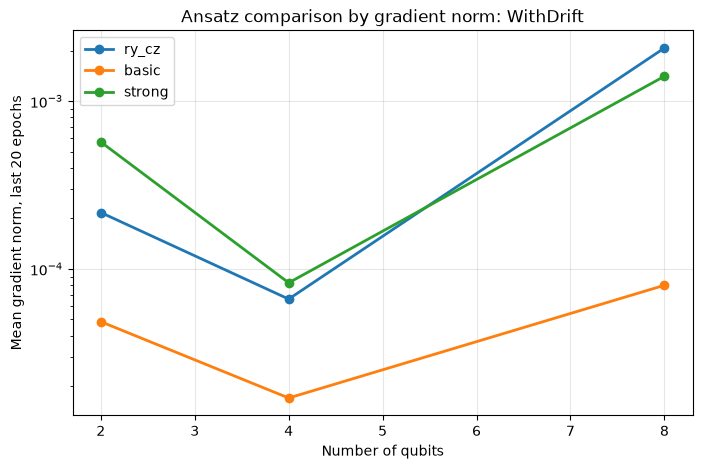

In [31]:
def plot_ansatz_gradient_comparison(df, dataset_name):
    part = df[df["Dataset"] == dataset_name]

    plt.figure(figsize=(8, 5))

    for ansatz_type in part["Ansatz"].unique():
        current = part[part["Ansatz"] == ansatz_type].sort_values("n_qubits")

        plt.plot(
            current["n_qubits"],
            current["Mean_Last20_Grad_Norm"],
            marker="o",
            linewidth=2,
            label=ansatz_type
        )

    plt.yscale("log")
    plt.xlabel("Number of qubits")
    plt.ylabel("Mean gradient norm, last 20 epochs")
    plt.title(f"Ansatz comparison by gradient norm: {dataset_name}")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.savefig(f"../graphics/ansatz_comparison_{dataset_name}.png", dpi=120)
    plt.show()


plot_ansatz_gradient_comparison(ansatz_df, "NoDrift")
plot_ansatz_gradient_comparison(ansatz_df, "WithDrift")

## Encoding Comparison: Angle vs IQP

Это центральный эксперимент научного вклада статьи — сравнение **Angle Encoding** и **IQP Encoding** реальных макроэкономических индикаторов (ключевая ставка ЦБ РФ, инфляция) на обоих режимах Concept Drift. Ansatz зафиксирован (`strong`, `StronglyEntanglingLayers`), меняются только способ кодирования и число кубитов, что позволяет изолировать эффект именно кодирования данных.

Напомним: `IQPEmbedding` требует точного совпадения числа признаков с числом кубитов, поэтому обе схемы здесь используют одинаково подготовленные признаки через `prepare_quantum_features`.

In [32]:
encoding_results = []
encoding_histories = {}

for dataset_name, X_train, X_test, y_train, y_test in [
    ("NoDrift", X_NoDrift_train, X_NoDrift_test, y_NoDrift_train, y_NoDrift_test),
    ("WithDrift", X_WithDrift_train, X_WithDrift_test, y_WithDrift_train, y_WithDrift_test)
]:
    for q in [2, 4, 8]:
        X_train_q, X_test_q = prepare_quantum_features(X_train, X_test, q)

        for encoding in ["angle", "iqp"]:
            print(f"\nDataset: {dataset_name} | Encoding: {encoding} | Qubits: {q}")

            model = VQCAnsatz(
                n_qubits=q,
                n_layers=2,
                ansatz_type="strong",
                encoding=encoding,
                init_scale=0.01
            )

            history = fit_with_gradient_logging(
                model,
                X_train_q,
                y_train,
                epochs=150,
                lr=0.05,
                optimizer_name="adam"
            )

            y_pred = model(torch.tensor(X_test_q, dtype=torch.float32)).detach().numpy()
            y_pred = (y_pred > 0.5).astype(int)

            encoding_results.append({
                "Dataset": dataset_name,
                "Encoding": encoding,
                "n_qubits": q,
                "Final_Loss": history["loss"][-1],
                "Mean_Last20_Grad_Norm": np.mean(history["grad_norm"][-20:]),
                "Mean_Last20_Grad_Var": np.mean(history["grad_var"][-20:]),
                "Accuracy": accuracy_score(y_test, y_pred),
                "Precision": precision_score(y_test, y_pred, zero_division=0),
                "Recall": recall_score(y_test, y_pred, zero_division=0),
                "F1": f1_score(y_test, y_pred, zero_division=0)
            })

            key = f"{dataset_name}_{encoding}_{q}"
            encoding_histories[key] = history


Dataset: NoDrift | Encoding: angle | Qubits: 2
Epoch 000 | loss=0.79787 | grad_norm=2.358e-03 | grad_var=4.286e-07
Epoch 050 | loss=0.61773 | grad_norm=1.732e-02 | grad_var=2.623e-05
Epoch 100 | loss=0.61269 | grad_norm=1.687e-03 | grad_var=1.997e-07

Dataset: NoDrift | Encoding: iqp | Qubits: 2
Epoch 000 | loss=0.79774 | grad_norm=5.504e-02 | grad_var=2.632e-04
Epoch 050 | loss=0.63094 | grad_norm=1.719e-02 | grad_var=2.444e-05
Epoch 100 | loss=0.62203 | grad_norm=1.703e-03 | grad_var=2.636e-07

Dataset: NoDrift | Encoding: angle | Qubits: 4
Epoch 000 | loss=0.66122 | grad_norm=2.755e-04 | grad_var=2.920e-09
Epoch 050 | loss=0.63215 | grad_norm=8.161e-03 | grad_var=2.627e-06
Epoch 100 | loss=0.62783 | grad_norm=7.301e-04 | grad_var=2.231e-08

Dataset: NoDrift | Encoding: iqp | Qubits: 4
Epoch 000 | loss=0.67677 | grad_norm=2.888e-02 | grad_var=3.574e-05
Epoch 050 | loss=0.64150 | grad_norm=2.634e-03 | grad_var=3.002e-07
Epoch 100 | loss=0.63785 | grad_norm=1.358e-03 | grad_var=6.462e

In [33]:
encoding_df = pd.DataFrame(encoding_results)
encoding_df

,Dataset,Encoding,n_qubits,Final_Loss,Mean_Last20_Grad_Norm,Mean_Last20_Grad_Var,Accuracy,Precision,Recall,F1
0,NoDrift,angle,2,0.612667,0.000185,3.529167e-09,0.644444,0.615385,0.727273,0.666667
1,NoDrift,iqp,2,0.621980,0.000208,3.333109e-09,0.544444,0.560000,0.318182,0.405797
2,NoDrift,angle,4,0.627826,0.000112,5.408154e-10,0.577778,0.562500,0.613636,0.586957
3,NoDrift,iqp,4,0.632396,0.003228,4.452926e-07,0.700000,0.774194,0.545455,0.640000
4,NoDrift,angle,8,0.627834,0.000252,1.356401e-09,0.522222,0.516129,0.363636,0.426667
5,NoDrift,iqp,8,0.659258,0.000306,2.029285e-09,0.700000,0.697674,0.681818,0.689655
6,WithDrift,angle,2,0.652042,0.000561,2.824955e-08,0.644444,0.684211,0.333333,0.448276
7,WithDrift,iqp,2,0.604081,0.001492,2.082648e-07,0.777778,0.806452,0.641026,0.714286
8,WithDrift,angle,4,0.600097,0.000113,5.542011e-10,0.655556,0.722222,0.333333,0.456140
9,WithDrift,iqp,4,0.629301,0.000114,5.565692e-10,0.666667,0.695652,0.410256,0.516129


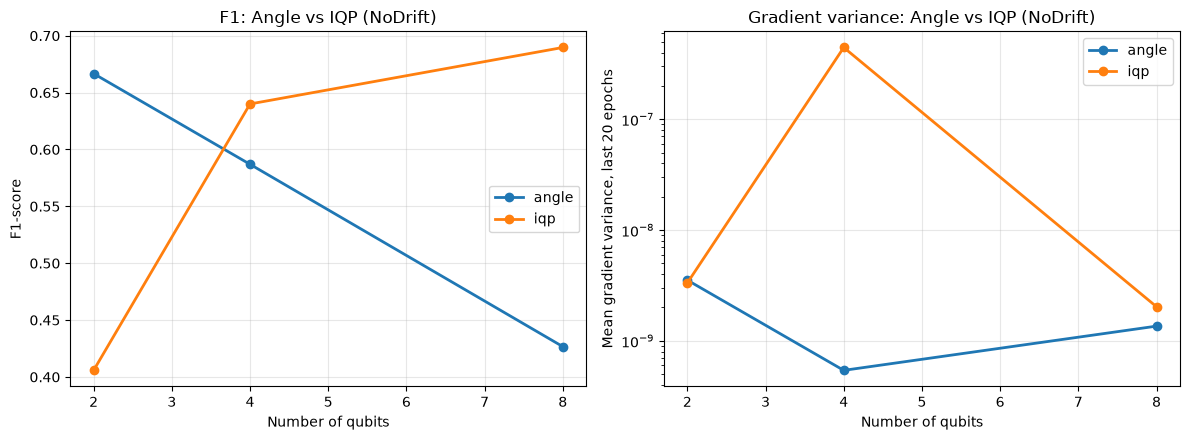

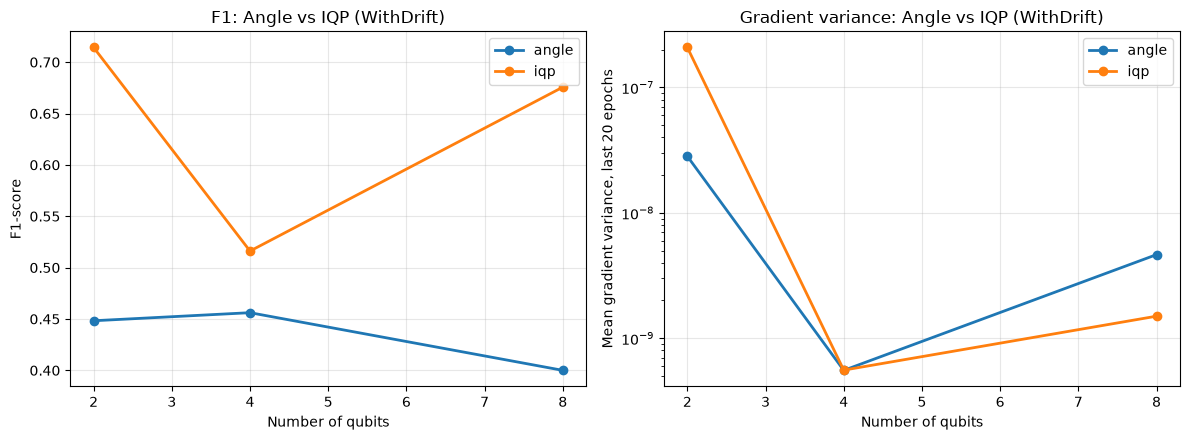

In [34]:
def plot_encoding_comparison(df, dataset_name):
    part = df[df["Dataset"] == dataset_name]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    for encoding in part["Encoding"].unique():
        current = part[part["Encoding"] == encoding].sort_values("n_qubits")
        axes[0].plot(current["n_qubits"], current["F1"], marker="o", linewidth=2, label=encoding)
        axes[1].plot(current["n_qubits"], current["Mean_Last20_Grad_Var"], marker="o", linewidth=2, label=encoding)

    axes[0].set_xlabel("Number of qubits"); axes[0].set_ylabel("F1-score")
    axes[0].set_title(f"F1: Angle vs IQP ({dataset_name})")

    axes[1].set_xlabel("Number of qubits"); axes[1].set_ylabel("Mean gradient variance, last 20 epochs")
    axes[1].set_yscale("log")
    axes[1].set_title(f"Gradient variance: Angle vs IQP ({dataset_name})")

    for ax in axes:
        ax.grid(alpha=0.3); ax.legend()

    plt.tight_layout()
    plt.savefig(f"../graphics/encoding_comparison_{dataset_name}.png", dpi=120)
    plt.show()


plot_encoding_comparison(encoding_df, "NoDrift")
plot_encoding_comparison(encoding_df, "WithDrift")

### Does Concept Drift accelerate Barren Plateau?

Сведём результаты `Encoding Comparison` в одну сравнительную таблицу по режимам `NoDrift` / `WithDrift`, чтобы напрямую проверить гипотезу статьи: ускоряет ли Concept Drift наступление Barren Plateau (падение `Mean_Last20_Grad_Var`) при фиксированной схеме и числе кубитов.

In [35]:
drift_effect = encoding_df.pivot_table(
    index=["Encoding", "n_qubits"],
    columns="Dataset",
    values=["F1", "Mean_Last20_Grad_Var"]
)
drift_effect

F1           Mean_Last20_Grad_Var              
Dataset             NoDrift WithDrift              NoDrift     WithDrift
Encoding n_qubits                                                       
angle    2         0.666667  0.448276         3.529167e-09  2.824955e-08
         4         0.586957  0.456140         5.408154e-10  5.542011e-10
         8         0.426667  0.400000         1.356401e-09  4.641405e-09
iqp      2         0.405797  0.714286         3.333109e-09  2.082648e-07
         4         0.640000  0.516129         4.452926e-07  5.565692e-10
         8         0.689655  0.675676         2.029285e-09  1.498640e-09

## Dynamic Ansatz Rebuilding

После диагностики можно сформулировать стратегию обхода Barren Plateaus. Вместо того чтобы заранее фиксировать сложную квантовую схему, модель начинает обучение с простой структуры. Далее схема изменяется в зависимости от поведения функции потерь и градиентов.

Для принятия решения используются две величины:

$$
\Delta C = \bar{C}_{prev} - \bar{C}_{curr}
$$

где:

- $\Delta C$ — улучшение функции потерь;
- $\bar{C}_{prev}$ — среднее значение loss на предыдущем окне эпох;
- $\bar{C}_{curr}$ — среднее значение loss на текущем окне эпох.

По сравнению с прошлой статьёй добавлен **drift-aware триггер**: если обучение проходит на участке с высоким уровнем Concept Drift (`drift_flag=True`), при обнаружении `barren_plateau` схема сбрасывается сразу к минимальному Ansatz (`ry_cz`, 1 слой), а не упрощается на один шаг — гипотеза в том, что при сильном дрейфе "мягкое" упрощение недостаточно.

In [36]:
def detect_training_problem(history, loss_window=20, grad_threshold=1e-4, min_loss_improvement=1e-3):
    losses = np.array(history["loss"])
    grad_norms = np.array(history["grad_norm"])

    if len(losses) < loss_window * 2:
        return "not_enough_history"

    previous_loss = losses[-2 * loss_window:-loss_window].mean()
    current_loss = losses[-loss_window:].mean()

    loss_improvement = previous_loss - current_loss
    current_grad_norm = grad_norms[-loss_window:].mean()

    if loss_improvement < min_loss_improvement and current_grad_norm < grad_threshold:
        return "barren_plateau"

    if loss_improvement < min_loss_improvement and current_grad_norm >= grad_threshold:
        return "expressivity_limit"

    return "normal_training"

### Adaptive Ansatz Selection Algorithm

Логика адаптивной стратегии:

1. начать с простой схемы `ry_cz`;
2. обучить модель несколько эпох;
3. определить режим обучения;
4. если возник Barren Plateau — упростить схему (либо принудительно сбросить её к минимальной, если участок отнесён к `WithDrift`);
5. если не хватает выразительности — перейти к более сложной схеме;
6. сохранить историю пересборки.

Функция дополнительно принимает параметры `encoding` (`angle`/`iqp`) и `drift_flag`, чтобы можно было запускать адаптивную стратегию для обоих способов кодирования на обоих режимах дрейфа.

In [37]:
def run_adaptive_ansatz_experiment(
    X_train,
    X_test,
    y_train,
    y_test,
    dataset_name,
    n_qubits,
    encoding="angle",
    drift_flag=False,
    epochs_per_stage=100,
    lr=0.05,
    grad_threshold=1e-4
):
    ansatz_sequence = ["ry_cz", "basic", "strong"]

    current_idx = 0
    current_layers = 1

    adaptive_history = {
        "loss": [],
        "grad_norm": [],
        "grad_var": [],
        "grad_mean_abs": [],
        "grad_max_abs": [],
        "stage": [],
        "ansatz": [],
        "layers": []
    }

    rebuild_log = []

    X_train_q, X_test_q = prepare_quantum_features(X_train, X_test, n_qubits)

    for stage in range(3):
        current_ansatz = ansatz_sequence[current_idx]

        print(
            f"\nStage {stage} | "
            f"Dataset: {dataset_name} | "
            f"Encoding: {encoding} | "
            f"Qubits: {n_qubits} | "
            f"Ansatz: {current_ansatz} | "
            f"Layers: {current_layers}"
        )

        model = VQCAnsatz(
            n_qubits=n_qubits,
            n_layers=current_layers,
            ansatz_type=current_ansatz,
            encoding=encoding,
            init_scale=0.01
        )

        history = fit_with_gradient_logging(
            model,
            X_train_q,
            y_train,
            epochs=epochs_per_stage,
            lr=lr,
            optimizer_name="adam"
        )

        for key in ["loss", "grad_norm", "grad_var", "grad_mean_abs", "grad_max_abs"]:
            adaptive_history[key].extend(history[key])

        adaptive_history["stage"].extend([stage] * len(history["loss"]))
        adaptive_history["ansatz"].extend([current_ansatz] * len(history["loss"]))
        adaptive_history["layers"].extend([current_layers] * len(history["loss"]))

        problem_type = detect_training_problem(
            history,
            grad_threshold=grad_threshold
        )

        if problem_type == "normal_training":
            action = "keep_current_ansatz"
            rebuild_log.append({
                "stage": stage,
                "problem_type": problem_type,
                "action": action,
                "ansatz": current_ansatz,
                "layers": current_layers
            })
            break

        if problem_type == "expressivity_limit":
            if current_idx < len(ansatz_sequence) - 1:
                current_idx += 1
                action = f"switch_to_{ansatz_sequence[current_idx]}"
            else:
                current_layers += 1
                action = f"increase_layers_to_{current_layers}"

        elif problem_type == "barren_plateau":
            if drift_flag:
                current_idx = 0
                current_layers = 1
                action = "drift_triggered_reset_to_ry_cz"
            else:
                current_idx = max(0, current_idx - 1)
                current_layers = 1
                action = f"simplify_to_{ansatz_sequence[current_idx]}"

        else:
            action = "no_action"

        rebuild_log.append({
            "stage": stage,
            "problem_type": problem_type,
            "action": action,
            "ansatz": current_ansatz,
            "layers": current_layers
        })

        print(f"Detected problem: {problem_type}")
        print(f"Action: {action}")

    y_pred = model(torch.tensor(X_test_q, dtype=torch.float32)).detach().numpy()
    y_pred = (y_pred > 0.5).astype(int)

    final_result = {
        "Dataset": dataset_name,
        "Model": "AdaptiveAnsatzVQC",
        "Encoding": encoding,
        "n_qubits": n_qubits,
        "Final_Ansatz": current_ansatz,
        "Final_Layers": current_layers,
        "Final_Loss": adaptive_history["loss"][-1],
        "Mean_Last20_Grad_Norm": np.mean(adaptive_history["grad_norm"][-20:]),
        "Mean_Last20_Grad_Var": np.mean(adaptive_history["grad_var"][-20:]),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0)
    }

    return final_result, adaptive_history, rebuild_log

### Adaptive Rebuilding Experiment

Теперь запустим адаптивную стратегию для обоих режимов дрейфа, обоих способов кодирования и разного числа кубитов. Цель эксперимента — проверить, позволяет ли динамическая пересборка схемы (в том числе drift-aware триггер) удерживать градиенты от слишком быстрого исчезновения именно на участках с высоким Concept Drift.


Stage 0 | Dataset: NoDrift | Encoding: angle | Qubits: 2 | Ansatz: ry_cz | Layers: 1
Epoch 000 | loss=0.76907 | grad_norm=9.366e-04 | grad_var=4.386e-07
Epoch 050 | loss=0.68733 | grad_norm=1.002e-02 | grad_var=5.020e-05
Detected problem: expressivity_limit
Action: switch_to_basic

Stage 1 | Dataset: NoDrift | Encoding: angle | Qubits: 2 | Ansatz: basic | Layers: 1
Epoch 000 | loss=0.76882 | grad_norm=5.536e-02 | grad_var=1.533e-03
Epoch 050 | loss=0.64752 | grad_norm=1.723e-02 | grad_var=1.484e-04
Detected problem: expressivity_limit
Action: switch_to_strong

Stage 2 | Dataset: NoDrift | Encoding: angle | Qubits: 2 | Ansatz: strong | Layers: 1
Epoch 000 | loss=0.67585 | grad_norm=3.190e-04 | grad_var=1.883e-08
Epoch 050 | loss=0.66381 | grad_norm=1.984e-03 | grad_var=7.573e-07
Detected problem: expressivity_limit
Action: increase_layers_to_2


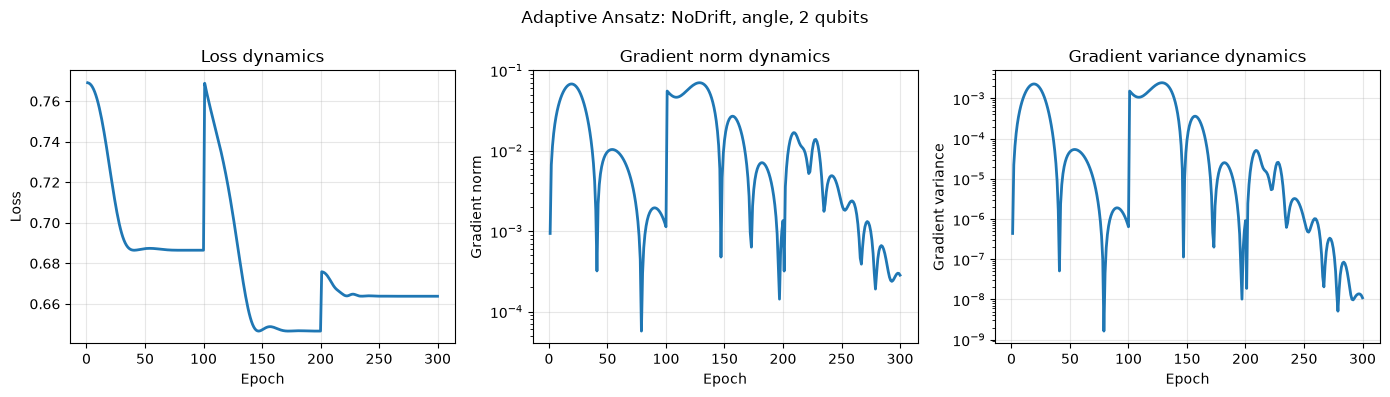


Stage 0 | Dataset: NoDrift | Encoding: iqp | Qubits: 2 | Ansatz: ry_cz | Layers: 1
Epoch 000 | loss=0.77095 | grad_norm=3.799e-02 | grad_var=7.216e-04
Epoch 050 | loss=0.66016 | grad_norm=1.371e-02 | grad_var=9.403e-05
Detected problem: expressivity_limit
Action: switch_to_basic

Stage 1 | Dataset: NoDrift | Encoding: iqp | Qubits: 2 | Ansatz: basic | Layers: 1
Epoch 000 | loss=0.77093 | grad_norm=3.041e-03 | grad_var=4.624e-06
Epoch 050 | loss=0.67436 | grad_norm=2.022e-02 | grad_var=2.044e-04
Detected problem: expressivity_limit
Action: switch_to_strong

Stage 2 | Dataset: NoDrift | Encoding: iqp | Qubits: 2 | Ansatz: strong | Layers: 1
Epoch 000 | loss=0.70637 | grad_norm=6.229e-02 | grad_var=6.514e-04
Epoch 050 | loss=0.64317 | grad_norm=7.837e-03 | grad_var=1.160e-05
Detected problem: expressivity_limit
Action: increase_layers_to_2


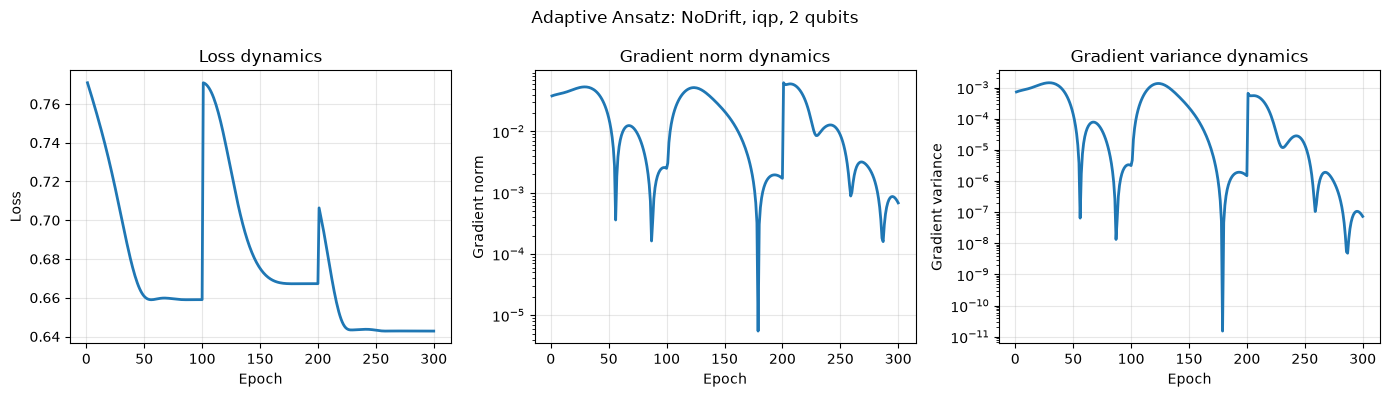


Stage 0 | Dataset: NoDrift | Encoding: angle | Qubits: 4 | Ansatz: ry_cz | Layers: 1
Epoch 000 | loss=0.76907 | grad_norm=5.575e-06 | grad_var=7.770e-12
Epoch 050 | loss=0.68733 | grad_norm=1.002e-02 | grad_var=2.508e-05
Detected problem: expressivity_limit
Action: switch_to_basic

Stage 1 | Dataset: NoDrift | Encoding: angle | Qubits: 4 | Ansatz: basic | Layers: 1
Epoch 000 | loss=0.67689 | grad_norm=1.207e-02 | grad_var=2.472e-05
Epoch 050 | loss=0.67013 | grad_norm=7.356e-04 | grad_var=1.682e-07
Detected problem: expressivity_limit
Action: switch_to_strong

Stage 2 | Dataset: NoDrift | Encoding: angle | Qubits: 4 | Ansatz: strong | Layers: 1
Epoch 000 | loss=0.67699 | grad_norm=2.223e-04 | grad_var=3.251e-09
Epoch 050 | loss=0.67018 | grad_norm=6.130e-04 | grad_var=3.298e-08
Detected problem: barren_plateau
Action: simplify_to_basic


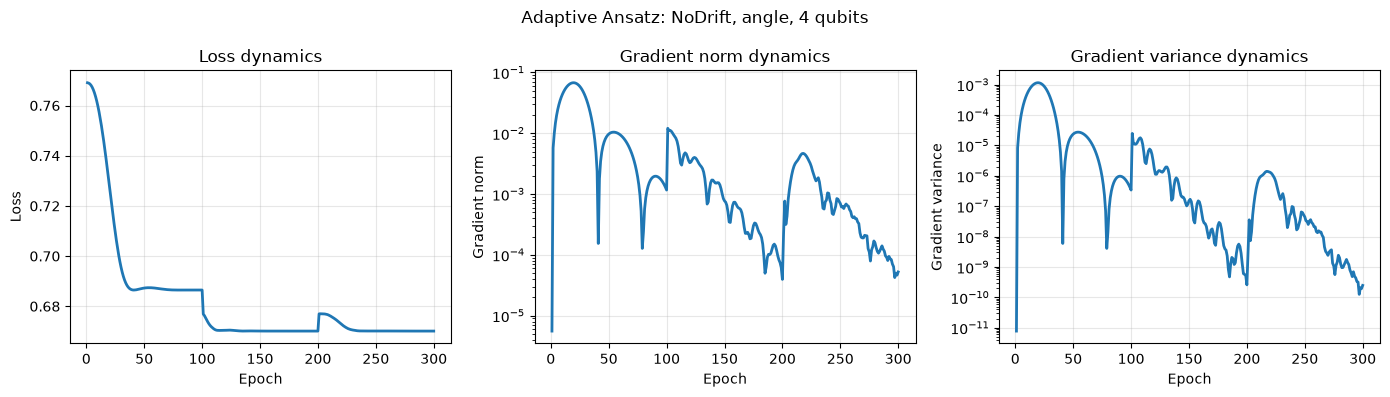


Stage 0 | Dataset: NoDrift | Encoding: iqp | Qubits: 4 | Ansatz: ry_cz | Layers: 1
Epoch 000 | loss=0.70482 | grad_norm=2.652e-02 | grad_var=1.758e-04
Epoch 050 | loss=0.67224 | grad_norm=2.505e-03 | grad_var=1.569e-06
Detected problem: expressivity_limit
Action: switch_to_basic

Stage 1 | Dataset: NoDrift | Encoding: iqp | Qubits: 4 | Ansatz: basic | Layers: 1
Epoch 000 | loss=0.69846 | grad_norm=3.756e-02 | grad_var=3.505e-04
Epoch 050 | loss=0.66116 | grad_norm=4.366e-03 | grad_var=5.060e-06
Detected problem: expressivity_limit
Action: switch_to_strong

Stage 2 | Dataset: NoDrift | Encoding: iqp | Qubits: 4 | Ansatz: strong | Layers: 1
Epoch 000 | loss=0.69842 | grad_norm=1.094e-02 | grad_var=8.961e-06
Epoch 050 | loss=0.65115 | grad_norm=4.337e-03 | grad_var=1.488e-06
Detected problem: expressivity_limit
Action: increase_layers_to_2


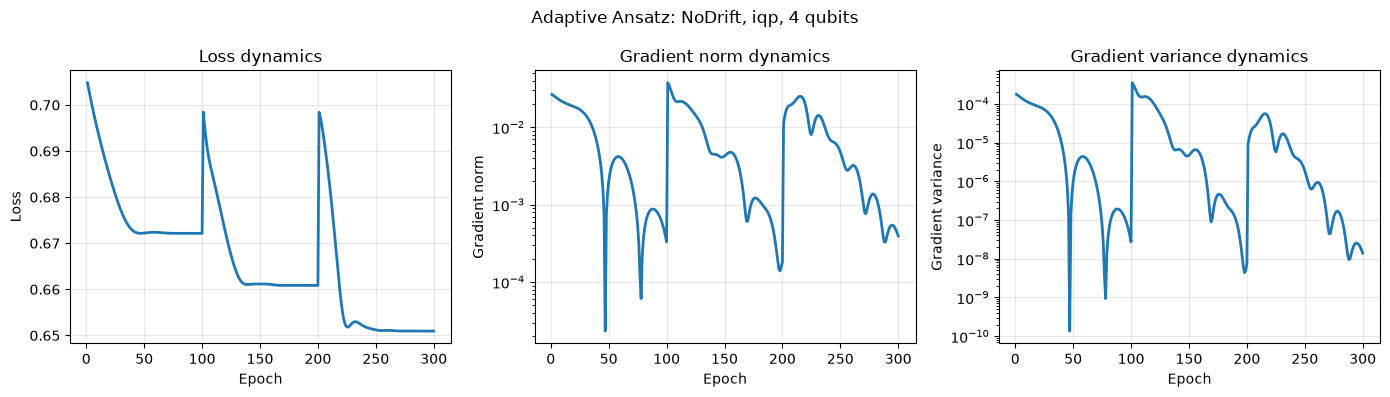


Stage 0 | Dataset: NoDrift | Encoding: angle | Qubits: 8 | Ansatz: ry_cz | Layers: 1
Epoch 000 | loss=0.76906 | grad_norm=1.470e-03 | grad_var=2.700e-07
Epoch 050 | loss=0.68733 | grad_norm=1.002e-02 | grad_var=1.255e-05
Detected problem: expressivity_limit
Action: switch_to_basic

Stage 1 | Dataset: NoDrift | Encoding: angle | Qubits: 8 | Ansatz: basic | Layers: 1
Epoch 000 | loss=0.67743 | grad_norm=2.994e-02 | grad_var=1.275e-04
Epoch 050 | loss=0.66123 | grad_norm=1.865e-03 | grad_var=4.969e-07
Detected problem: expressivity_limit
Action: switch_to_strong

Stage 2 | Dataset: NoDrift | Encoding: angle | Qubits: 8 | Ansatz: strong | Layers: 1
Epoch 000 | loss=0.67779 | grad_norm=4.691e-04 | grad_var=7.688e-09
Epoch 050 | loss=0.66149 | grad_norm=2.220e-03 | grad_var=2.016e-07
Detected problem: expressivity_limit
Action: increase_layers_to_2


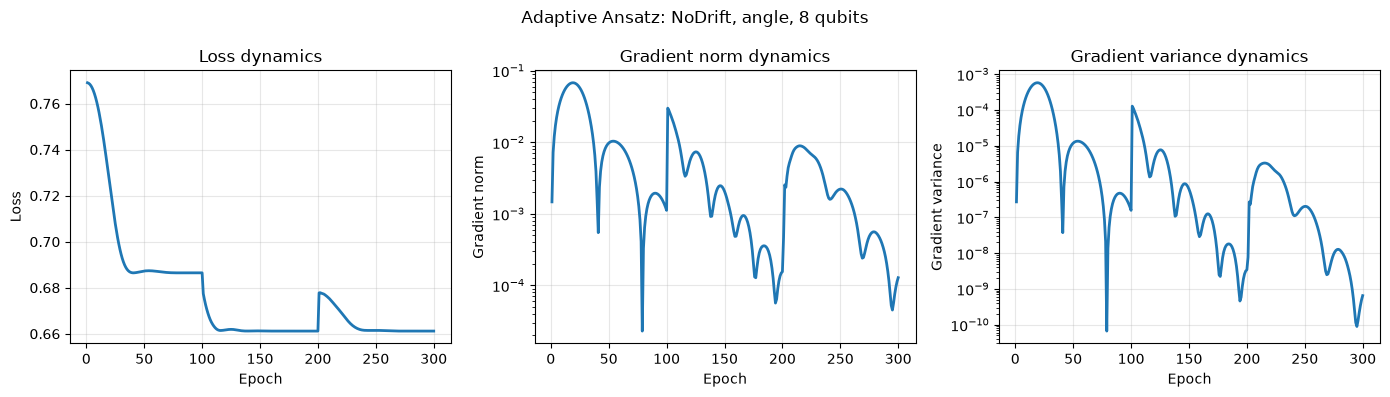


Stage 0 | Dataset: NoDrift | Encoding: iqp | Qubits: 8 | Ansatz: ry_cz | Layers: 1
Epoch 000 | loss=0.68736 | grad_norm=1.934e-03 | grad_var=4.675e-07
Epoch 050 | loss=0.68712 | grad_norm=1.022e-04 | grad_var=1.306e-09
Detected problem: barren_plateau
Action: simplify_to_ry_cz

Stage 1 | Dataset: NoDrift | Encoding: iqp | Qubits: 8 | Ansatz: ry_cz | Layers: 1
Epoch 000 | loss=0.68739 | grad_norm=2.058e-03 | grad_var=5.297e-07
Epoch 050 | loss=0.68712 | grad_norm=1.172e-04 | grad_var=1.717e-09
Detected problem: barren_plateau
Action: simplify_to_ry_cz

Stage 2 | Dataset: NoDrift | Encoding: iqp | Qubits: 8 | Ansatz: ry_cz | Layers: 1
Epoch 000 | loss=0.68742 | grad_norm=2.174e-03 | grad_var=5.905e-07
Epoch 050 | loss=0.68712 | grad_norm=1.065e-04 | grad_var=1.418e-09
Detected problem: barren_plateau
Action: simplify_to_ry_cz


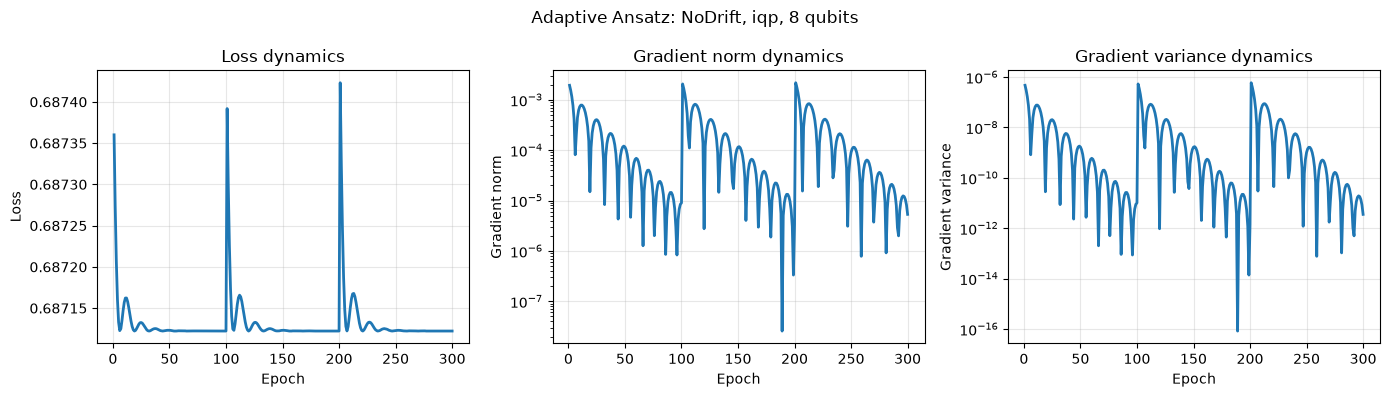


Stage 0 | Dataset: WithDrift | Encoding: angle | Qubits: 2 | Ansatz: ry_cz | Layers: 1
Epoch 000 | loss=0.74055 | grad_norm=1.249e-03 | grad_var=7.802e-07
Epoch 050 | loss=0.69339 | grad_norm=7.464e-03 | grad_var=2.786e-05
Detected problem: expressivity_limit
Action: switch_to_basic

Stage 1 | Dataset: WithDrift | Encoding: angle | Qubits: 2 | Ansatz: basic | Layers: 1
Epoch 000 | loss=0.74124 | grad_norm=9.630e-02 | grad_var=4.637e-03
Epoch 050 | loss=0.69831 | grad_norm=6.960e-03 | grad_var=2.422e-05
Detected problem: expressivity_limit
Action: switch_to_strong

Stage 2 | Dataset: WithDrift | Encoding: angle | Qubits: 2 | Ansatz: strong | Layers: 1
Epoch 000 | loss=0.74599 | grad_norm=2.918e-03 | grad_var=1.578e-06
Epoch 050 | loss=0.60973 | grad_norm=1.350e-02 | grad_var=3.384e-05
Detected problem: expressivity_limit
Action: increase_layers_to_2


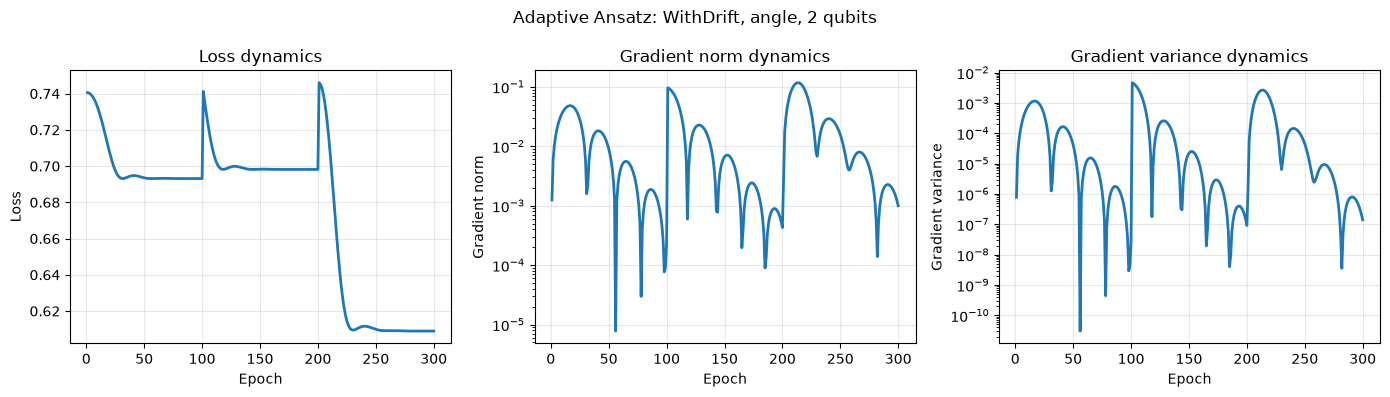


Stage 0 | Dataset: WithDrift | Encoding: iqp | Qubits: 2 | Ansatz: ry_cz | Layers: 1
Epoch 000 | loss=0.75651 | grad_norm=2.335e-02 | grad_var=2.727e-04
Epoch 050 | loss=0.66428 | grad_norm=5.807e-03 | grad_var=1.686e-05
Detected problem: expressivity_limit
Action: switch_to_basic

Stage 1 | Dataset: WithDrift | Encoding: iqp | Qubits: 2 | Ansatz: basic | Layers: 1
Epoch 000 | loss=0.75647 | grad_norm=4.298e-02 | grad_var=9.237e-04
Epoch 050 | loss=0.65981 | grad_norm=8.621e-03 | grad_var=3.717e-05
Detected problem: expressivity_limit
Action: switch_to_strong

Stage 2 | Dataset: WithDrift | Encoding: iqp | Qubits: 2 | Ansatz: strong | Layers: 1
Epoch 000 | loss=0.65075 | grad_norm=5.368e-02 | grad_var=4.793e-04
Epoch 050 | loss=0.63035 | grad_norm=1.377e-03 | grad_var=2.762e-07
Detected problem: expressivity_limit
Action: increase_layers_to_2


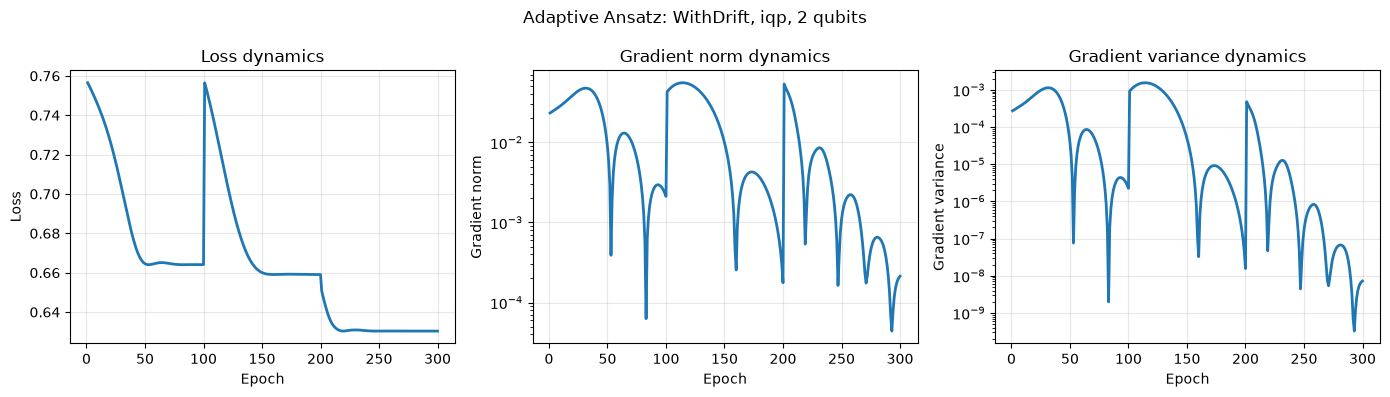


Stage 0 | Dataset: WithDrift | Encoding: angle | Qubits: 4 | Ansatz: ry_cz | Layers: 1
Epoch 000 | loss=0.74056 | grad_norm=6.582e-04 | grad_var=1.083e-07
Epoch 050 | loss=0.69341 | grad_norm=7.759e-03 | grad_var=1.505e-05
Detected problem: expressivity_limit
Action: switch_to_basic

Stage 1 | Dataset: WithDrift | Encoding: angle | Qubits: 4 | Ansatz: basic | Layers: 1
Epoch 000 | loss=0.69170 | grad_norm=7.569e-02 | grad_var=1.905e-03
Epoch 050 | loss=0.65029 | grad_norm=2.642e-02 | grad_var=1.166e-04


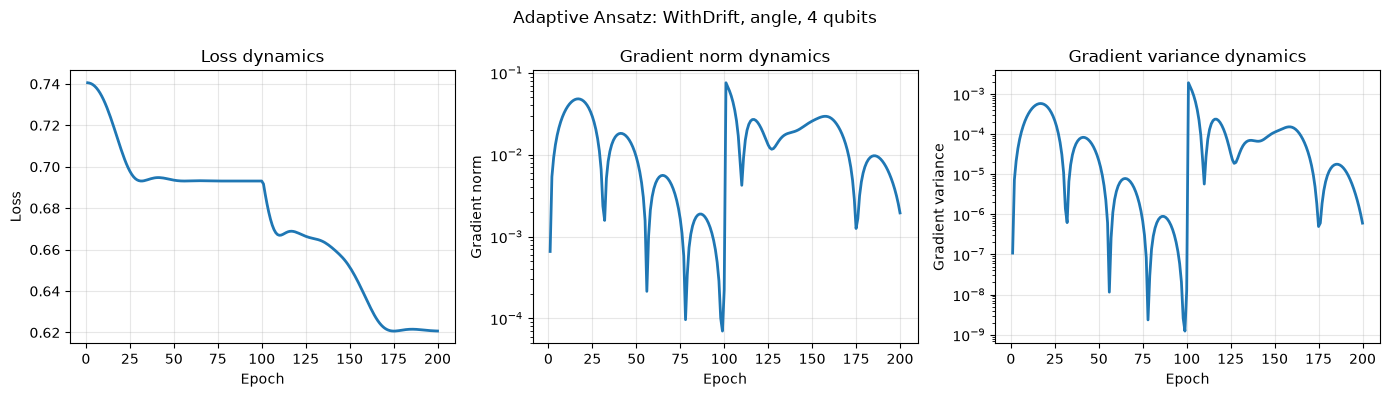


Stage 0 | Dataset: WithDrift | Encoding: iqp | Qubits: 4 | Ansatz: ry_cz | Layers: 1
Epoch 000 | loss=0.67804 | grad_norm=2.575e-02 | grad_var=1.657e-04
Epoch 050 | loss=0.66732 | grad_norm=5.832e-04 | grad_var=8.504e-08
Detected problem: expressivity_limit
Action: switch_to_basic

Stage 1 | Dataset: WithDrift | Encoding: iqp | Qubits: 4 | Ansatz: basic | Layers: 1
Epoch 000 | loss=0.70550 | grad_norm=3.120e-02 | grad_var=2.500e-04
Epoch 050 | loss=0.66963 | grad_norm=2.105e-03 | grad_var=1.284e-06
Detected problem: expressivity_limit
Action: switch_to_strong

Stage 2 | Dataset: WithDrift | Encoding: iqp | Qubits: 4 | Ansatz: strong | Layers: 1
Epoch 000 | loss=0.70523 | grad_norm=3.531e-02 | grad_var=9.561e-05
Epoch 050 | loss=0.66175 | grad_norm=3.230e-03 | grad_var=8.569e-07
Detected problem: expressivity_limit
Action: increase_layers_to_2


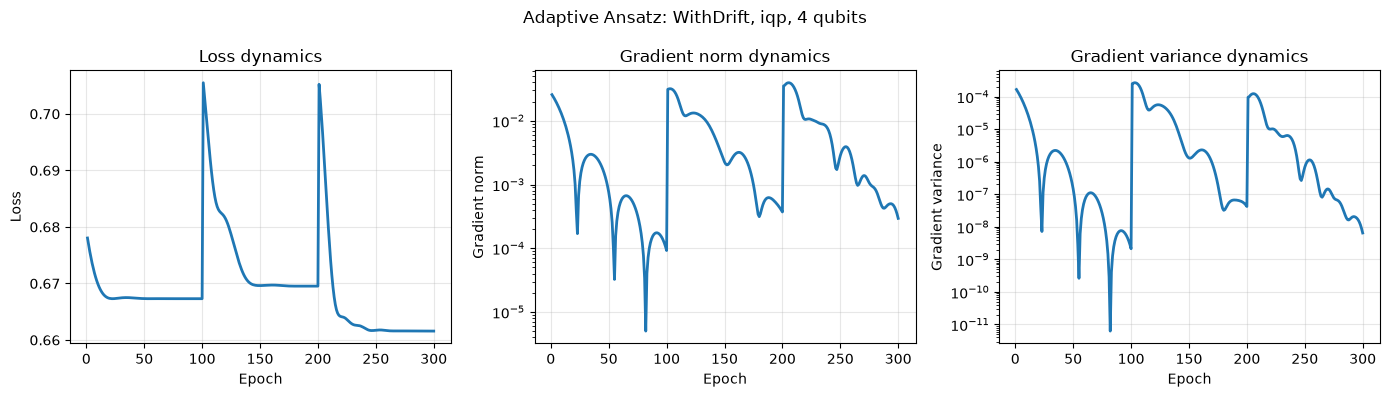


Stage 0 | Dataset: WithDrift | Encoding: angle | Qubits: 8 | Ansatz: ry_cz | Layers: 1
Epoch 000 | loss=0.74055 | grad_norm=1.271e-03 | grad_var=2.020e-07
Epoch 050 | loss=0.69339 | grad_norm=7.454e-03 | grad_var=6.945e-06
Detected problem: expressivity_limit
Action: switch_to_basic

Stage 1 | Dataset: WithDrift | Encoding: angle | Qubits: 8 | Ansatz: basic | Layers: 1
Epoch 000 | loss=0.69503 | grad_norm=1.996e-02 | grad_var=2.622e-05
Epoch 050 | loss=0.65238 | grad_norm=7.509e-03 | grad_var=8.038e-06
Detected problem: expressivity_limit
Action: switch_to_strong

Stage 2 | Dataset: WithDrift | Encoding: angle | Qubits: 8 | Ansatz: strong | Layers: 1
Epoch 000 | loss=0.69479 | grad_norm=1.995e-04 | grad_var=1.668e-09
Epoch 050 | loss=0.65311 | grad_norm=9.696e-03 | grad_var=4.087e-06
Detected problem: expressivity_limit
Action: increase_layers_to_2


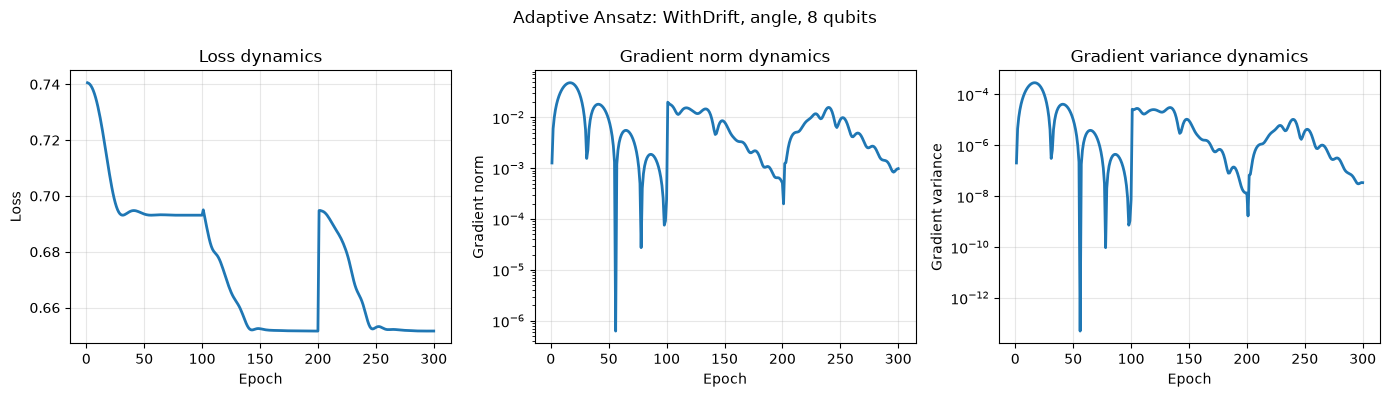


Stage 0 | Dataset: WithDrift | Encoding: iqp | Qubits: 8 | Ansatz: ry_cz | Layers: 1
Epoch 000 | loss=0.69957 | grad_norm=9.314e-03 | grad_var=1.084e-05
Epoch 050 | loss=0.68316 | grad_norm=2.654e-05 | grad_var=8.805e-11
Detected problem: expressivity_limit
Action: switch_to_basic

Stage 1 | Dataset: WithDrift | Encoding: iqp | Qubits: 8 | Ansatz: basic | Layers: 1
Epoch 000 | loss=0.72878 | grad_norm=2.242e-02 | grad_var=2.374e-05
Epoch 050 | loss=0.67294 | grad_norm=9.010e-03 | grad_var=1.149e-05


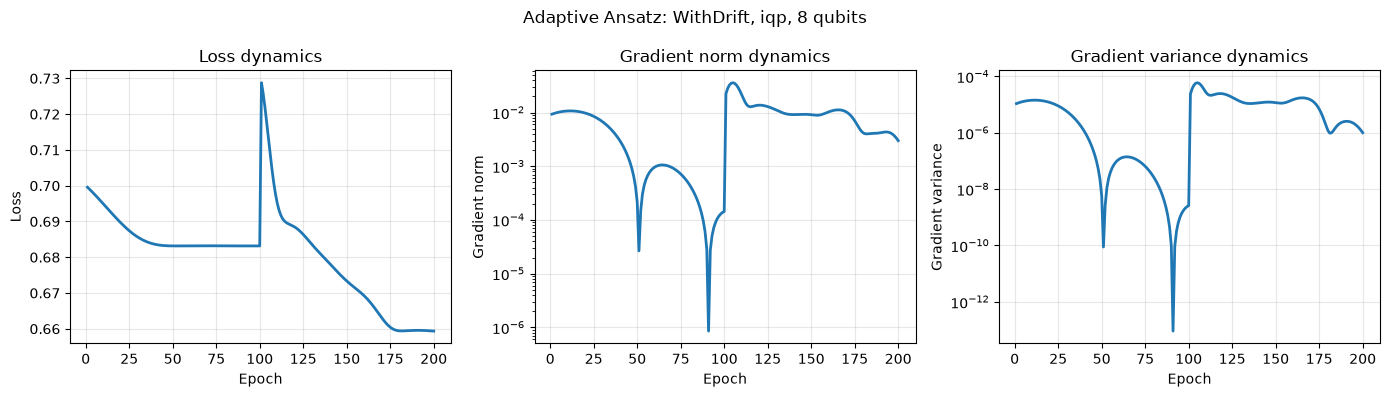

In [38]:
adaptive_results = []
adaptive_histories = {}
adaptive_logs = {}

for dataset_name, X_train, X_test, y_train, y_test in [
    ("NoDrift", X_NoDrift_train, X_NoDrift_test, y_NoDrift_train, y_NoDrift_test),
    ("WithDrift", X_WithDrift_train, X_WithDrift_test, y_WithDrift_train, y_WithDrift_test)
]:
    for q in [2, 4, 8]:
        for encoding in ["angle", "iqp"]:
            result, history, log = run_adaptive_ansatz_experiment(
                X_train=X_train,
                X_test=X_test,
                y_train=y_train,
                y_test=y_test,
                dataset_name=dataset_name,
                n_qubits=q,
                encoding=encoding,
                drift_flag=(dataset_name == "WithDrift"),
                epochs_per_stage=100,
                lr=0.05,
                grad_threshold=1e-4
            )

            adaptive_results.append(result)

            key = f"{dataset_name}_{encoding}_adaptive_{q}"
            adaptive_histories[key] = history
            adaptive_logs[key] = log

            plot_barren_plateau_diagnostics(
                history,
                title=f"Adaptive Ansatz: {dataset_name}, {encoding}, {q} qubits"
            )

In [39]:
adaptive_df = pd.DataFrame(adaptive_results)
adaptive_df

,Dataset,Model,Encoding,n_qubits,Final_Ansatz,Final_Layers,Final_Loss,Mean_Last20_Grad_Norm,Mean_Last20_Grad_Var,Accuracy,Precision,Recall,F1
0,NoDrift,AdaptiveAnsatzVQC,angle,2,strong,2,0.663784,0.000396,3.220967e-08,0.588889,0.629630,0.386364,0.478873
1,NoDrift,AdaptiveAnsatzVQC,iqp,2,strong,2,0.642811,0.000681,7.610585e-08,0.622222,0.656250,0.477273,0.552632
2,NoDrift,AdaptiveAnsatzVQC,angle,4,strong,1,0.670123,0.000092,7.545381e-10,0.500000,0.487179,0.431818,0.457831
3,NoDrift,AdaptiveAnsatzVQC,iqp,4,strong,2,0.650945,0.000578,3.410567e-08,0.600000,0.600000,0.545455,0.571429
4,NoDrift,AdaptiveAnsatzVQC,angle,8,strong,2,0.661181,0.000241,3.368924e-09,0.622222,0.580645,0.818182,0.679245
5,NoDrift,AdaptiveAnsatzVQC,iqp,8,ry_cz,1,0.687122,0.000011,1.915650e-11,0.544444,0.545455,0.409091,0.467532
6,WithDrift,AdaptiveAnsatzVQC,angle,2,strong,2,0.608954,0.001553,4.336172e-07,0.611111,0.666667,0.205128,0.313725
7,WithDrift,AdaptiveAnsatzVQC,iqp,2,strong,2,0.630333,0.000312,2.354768e-08,0.555556,0.491525,0.743590,0.591837
8,WithDrift,AdaptiveAnsatzVQC,angle,4,basic,1,0.620712,0.006955,1.003267e-05,0.633333,0.800000,0.205128,0.326531
9,WithDrift,AdaptiveAnsatzVQC,iqp,4,strong,2,0.661581,0.000491,2.120490e-08,0.555556,0.466667,0.179487,0.259259


### Rebuilding Logs

Для исследовательской части важно не только итоговое качество, но и сам процесс принятия решений. Поэтому отдельно выведем таблицу, где видно, какой тип проблемы был обнаружен и какое действие было выполнено — в частности, срабатывал ли drift-triggered сброс схемы.

In [40]:
adaptive_log_rows = []

for experiment_name, logs in adaptive_logs.items():
    for row in logs:
        current_row = row.copy()
        current_row["Experiment"] = experiment_name
        adaptive_log_rows.append(current_row)

adaptive_log_df = pd.DataFrame(adaptive_log_rows)
adaptive_log_df

,stage,problem_type,action,ansatz,layers,Experiment
0,0,expressivity_limit,switch_to_basic,ry_cz,1,NoDrift_angle_adaptive_2
1,1,expressivity_limit,switch_to_strong,basic,1,NoDrift_angle_adaptive_2
2,2,expressivity_limit,increase_layers_to_2,strong,2,NoDrift_angle_adaptive_2
3,0,expressivity_limit,switch_to_basic,ry_cz,1,NoDrift_iqp_adaptive_2
4,1,expressivity_limit,switch_to_strong,basic,1,NoDrift_iqp_adaptive_2
5,2,expressivity_limit,increase_layers_to_2,strong,2,NoDrift_iqp_adaptive_2
6,0,expressivity_limit,switch_to_basic,ry_cz,1,NoDrift_angle_adaptive_4
7,1,expressivity_limit,switch_to_strong,basic,1,NoDrift_angle_adaptive_4
8,2,barren_plateau,simplify_to_basic,strong,1,NoDrift_angle_adaptive_4
9,0,expressivity_limit,switch_to_basic,ry_cz,1,NoDrift_iqp_adaptive_4


### Experimental Conclusion